# Sprint 3 Wake effects analysis

Goal: **Quantify how upstream turbines reduce the power production of downstream turbines due to wake effects.**
Inputs:
- Turbine positions (UTM)
- Wind direction (mast)
- Turbine Power (SCADA)
- Nacelle wind speed
- Turbine rotor diameter

1. Step 1: Wind farm geometry analysis
Tasks:
- Plot true farm layout
- Add mast positions
- Verify farm orienatation
Additional plots:
- Turbine spacing
- Nearest neighbor distances
- Compute distances between wind turbines $d= \sqrt{(x_2 - x_1)^2 + (y_2 - y_1) ^2}$

Outputs:
- Turbines layout plot
- Turbines spacing diagram
- Nearest neighbor map

2. Step 2: Wind direction statistics
Using:
- d31_1
- d31_2
Tasks:
- Wind direction histogram
- Wind rose
- Dominant wind sectors
Outputs:
- Wind rose
- Sector frequency plot

3. Step 3: Define upstream and downstream turbines

Combining wind direction + turbines coordinates

For each timestamp:
- Compute wind direction
- Project turbine positions onto wind direction
- Indentify upstream turbines

Outputs:
- Turbine alignment map
- Upstream/downstream relationships

4. Step 4- Select wake sectors
- Since not all directions need to be analyzed
- For example:
    - 260°–280° (west wind)
    - 240°–260° (SW wind)

5. Step 5- Power deficit analysis
- Now to power production comparison
- Power defined as $R= \frac{P_{\mathrm{downstream}}}{P_{\mathrm{upstream}}}$


6. Step 6- Wake visualization
- Make plots like
    - Wake map
    - Directional wake plots

7. Step 7- Compare with theory + some extension

For example comparison with theory and Jensen wake model
$$U = U_0 \left(1 - \frac{1-\sqrt{1-C_T}}{(1 + kx/D)^2}\right)$$
Where:
- $C_T$ - thrust coefficient
- $k$ - wake decay constant
- $x$ - downstream distance
- $D$ - rotor diameter



## Step 1 - Create a wind farm layout plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


rows = ["A","B","C","D","E","F"]
cols = [1,2,3,4,5,6,7]

dx = 220   # horizontal spacing (m)
dy = 180   # vertical spacing (m)

turbines = []

for r_idx, r in enumerate(rows):
    for c_idx, c in enumerate(cols):

        x = c_idx * dx
        y = -r_idx * dy

        # shift every row slightly to create diagonal farm rows
        x = x + r_idx * 70

        turbines.append({
            "turbine": f"{r}{c}",
            "row": r,
            "col": c,
            "x": x,
            "y": y
        })

layout_df = pd.DataFrame(turbines)

In [3]:
angle = 20
theta = np.radians(angle)

x = layout_df["x"].values
y = layout_df["y"].values

layout_df["x_plot"] = x*np.cos(theta) - y*np.sin(theta)
layout_df["y_plot"] = x*np.sin(theta) + y*np.cos(theta)

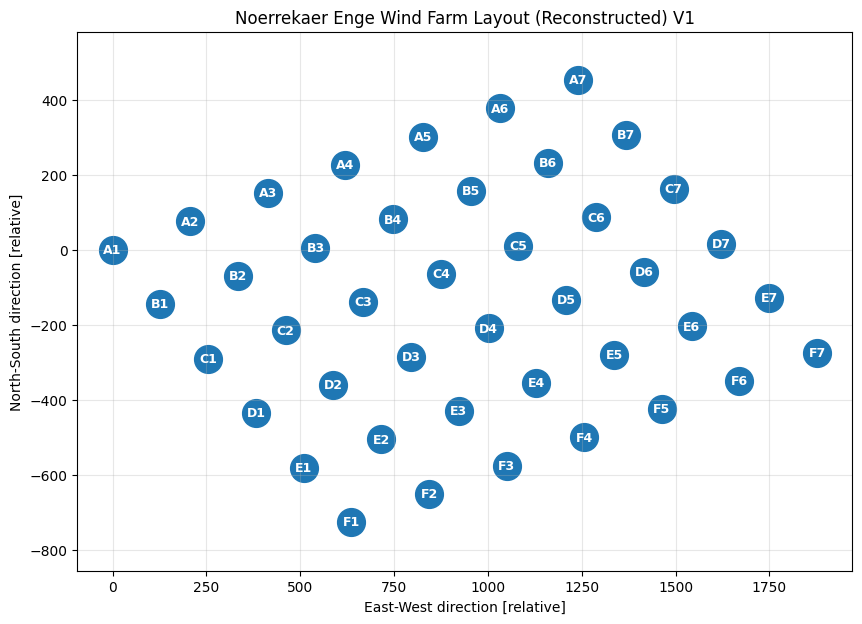

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    layout_df["x_plot"],
    layout_df["y_plot"],
    s=400
)

for _, r in layout_df.iterrows():
    plt.text(
        r["x_plot"],
        r["y_plot"],
        r["turbine"],
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        weight="bold"
    )

plt.title("Noerrekaer Enge Wind Farm Layout (Reconstructed) V1")
plt.xlabel("East-West direction [relative]")
plt.ylabel("North-South direction [relative]")
plt.grid(alpha=0.3)
plt.axis("equal")


plt.show()

In [5]:
rows = range(1, 8)

left_cols = ["A", "B", "C"]
right_cols = ["D", "E", "F"]

dx = 250          # spacing between columns
dy = 180          # spacing between turbines vertically
gap_extra = 350   # empty gap between C and D

turbines = []

# LEFT BLOCK
for c_idx, col in enumerate(left_cols):
    for r in rows:
        x = c_idx * dx
        y = (r - 1) * dy

        turbines.append({
            "turbine": f"{col}{r}",
            "col": col,
            "row_num": r,
            "x": x,
            "y": y
        })

# RIGHT BLOCK
x_right_start = len(left_cols) * dx + gap_extra

for c_idx, col in enumerate(right_cols):
    for r in rows:
        x = x_right_start + c_idx * dx
        y = (r - 1) * dy

        turbines.append({
            "turbine": f"{col}{r}",
            "col": col,
            "row_num": r,
            "x": x,
            "y": y
        })

layout_df = pd.DataFrame(turbines)
layout_df.head()

,turbine,col,row_num,x,y
0,A1,A,1,0,0
1,A2,A,2,0,180
2,A3,A,3,0,360
3,A4,A,4,0,540
4,A5,A,5,0,720


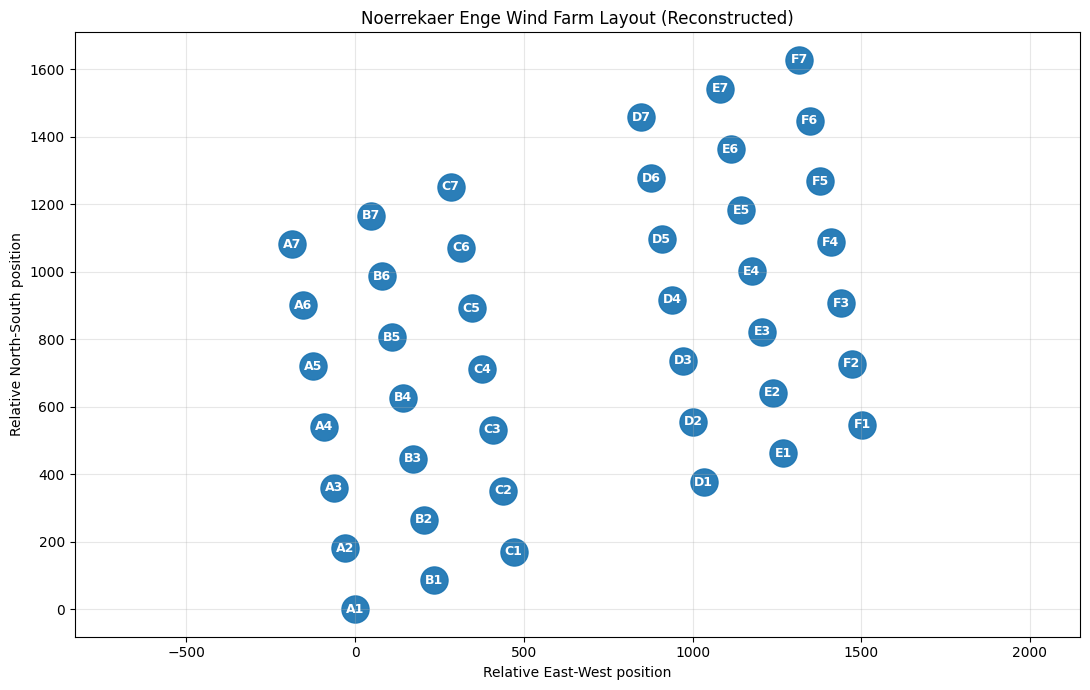

In [ ]:
shear_factor = 0.18

layout_df["x_sheared"] = layout_df["x"] + shear_factor * layout_df["y"]
layout_df["y_sheared"] = layout_df["y"]

angle_deg = 20   # try -15 to -25 if you want to tweak appearance
theta = np.radians(angle_deg)

x = layout_df["x_sheared"].values
y = layout_df["y_sheared"].values

layout_df["x_plot"] = x * np.cos(theta) - y * np.sin(theta)
layout_df["y_plot"] = x * np.sin(theta) + y * np.cos(theta)

plt.figure(figsize=(11, 7))

plt.scatter(
    layout_df["x_plot"],
    layout_df["y_plot"],
    s=380,
    alpha=0.95
)

for _, r in layout_df.iterrows():
    plt.text(
        r["x_plot"],
        r["y_plot"],
        r["turbine"],
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Noerrekaer Enge Wind Farm Layout (Reconstructed)")
plt.xlabel("Relative East-West position")
plt.ylabel("Relative North-South position")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()

plt.savefig('../figures/sprint3_wf_layout.png', dpi=300)
plt.show()

In [7]:
# Real coordinates for wind turbines
coords = {
"A1": (524960.60, 6317928.53),
"A2": (524915.27, 6318100.09),
"A3": (524869.96, 6318271.63),
"A4": (524824.63, 6318443.19),
"A5": (524779.31, 6318614.75),
"A6": (524734.00, 6318786.30),
"A7": (524688.67, 6318957.85),

"B1": (525185.73, 6317979.09),
"B2": (525139.65, 6318150.48),
"B3": (525093.56, 6318321.87),
"B4": (525047.47, 6318493.26),
"B5": (525001.39, 6318664.64),
"B6": (524955.30, 6318836.04),
"B7": (524909.22, 6319007.43),

"C1": (525398.46, 6318026.86),
"C2": (525349.10, 6318197.52),
"C3": (525299.73, 6318368.18),
"C4": (525250.37, 6318538.85),
"C5": (525200.99, 6318709.50),
"C6": (525151.63, 6318880.16),
"C7": (525102.26, 6319050.83),

"D1": (526128.28, 6318190.75),
"D2": (526086.51, 6318363.15),
"D3": (526044.74, 6318535.54),
"D4": (526002.95, 6318707.92),
"D5": (525961.18, 6318880.32),
"D6": (525919.41, 6319052.71),
"D7": (525877.64, 6319225.11),

"E1": (526349.18, 6318240.36),
"E2": (526306.86, 6318412.64),
"E3": (526264.56, 6318584.92),
"E4": (526222.24, 6318757.20),
"E5": (526179.92, 6318929.47),
"E6": (526137.61, 6319101.75),
"E7": (526095.29, 6319274.03),

"F1": (526552.91, 6318286.10),
"F2": (526509.22, 6318458.08),
"F3": (526465.52, 6318630.06),
"F4": (526421.84, 6318802.04),
"F5": (526378.15, 6318974.01),
"F6": (526334.45, 6319145.99),
"F7": (526290.76, 6319317.97)
}

layout_df = pd.DataFrame.from_dict(
    coords,
    orient='index',
    columns = ['x', 'y']
)
layout_df['turbine'] = layout_df.index
layout_df.reset_index(drop=True, inplace=True)

layout_df.head()

,x,y,turbine
0,524960.60,6317928.53,A1
1,524915.27,6318100.09,A2
2,524869.96,6318271.63,A3
3,524824.63,6318443.19,A4
4,524779.31,6318614.75,A5


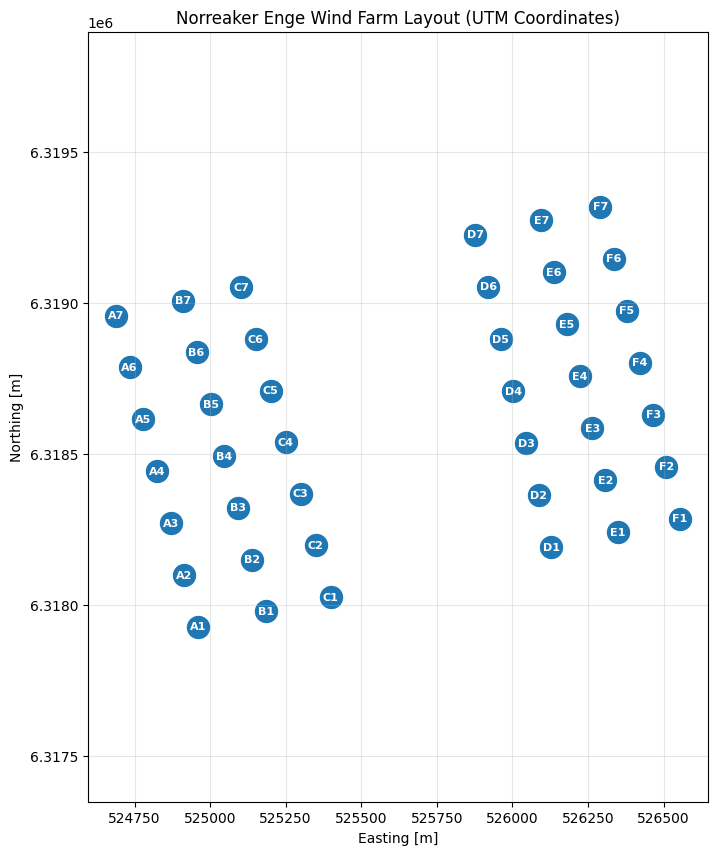

In [ ]:
plt.figure(figsize=(8,10))

plt.scatter(layout_df['x'], layout_df['y'], s=250)

for _, r in layout_df.iterrows():
    plt.text(
        r['x'],
        r['y'],
        r['turbine'],
        ha = 'center',
        va = 'center',
        color = 'white',
        fontsize = 8,
        weight = 'bold'
    )

plt.title('Norreaker Enge Wind Farm Layout (UTM Coordinates)')
plt.xlabel('Easting [m]')
plt.ylabel('Northing [m]')
plt.axis('equal')
plt.grid(alpha=0.3)

plt.savefig('../figures/sprint3_wf_layout_coords.png', dpi=300)
plt.show()

In [9]:
# Add mast positions

mast_coords = {
"M1": (524974.64, 6317875.37),
"M2": (526302.52, 6319101.24)
}

mast_df = pd.DataFrame.from_dict(
    mast_coords,
    orient = 'index',
    columns = ['x', 'y']
)

mast_df['mast'] = mast_df.index
mast_df.reset_index(drop=True, inplace=True)

mast_df

,x,y,mast
0,524974.64,6317875.37,M1
1,526302.52,6319101.24,M2


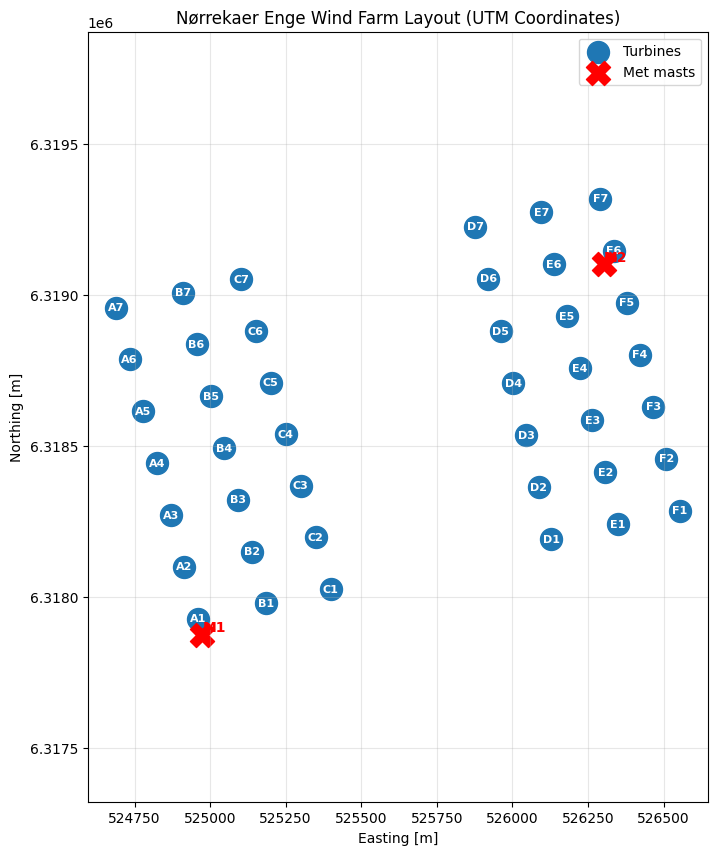

In [ ]:
plt.figure(figsize=(8,10))

# turbines
plt.scatter(
    layout_df["x"],
    layout_df["y"],
    s=250,
    label="Turbines"
)

# turbine labels
for _, r in layout_df.iterrows():
    plt.text(
        r["x"],
        r["y"],
        r["turbine"],
        ha="center",
        va="center",
        color="white",
        fontsize=8,
        weight="bold"
    )

# masts
plt.scatter(
    mast_df["x"],
    mast_df["y"],
    s=300,
    marker="X",
    color="red",
    label="Met masts"
)

# mast labels
for _, r in mast_df.iterrows():
    plt.text(
        r["x"],
        r["y"],
        r["mast"],
        ha="left",
        va="bottom",
        color="red",
        fontsize=10,
        weight="bold"
    )

plt.title("Nørrekaer Enge Wind Farm Layout (UTM Coordinates)")
plt.xlabel("Easting [m]")
plt.ylabel("Northing [m]")

plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()

plt.savefig('../figures/sprint3_wf_layout_masts.png', dpi=300)
plt.show()

### Step 1.2 - Turbine spacing validation

Since documenatation about researched wind farm gives info about spacing of wind turbines. It can be also validated
- D = 28m
- Spacing in rows = 6D
- Spacing between rows = 7-8D

Spacing between 2 wind turbines:
$$d = \sqrt{ (x_2 - x_1)^2 + (y_2 - y_1)^2 }$$
Then conver it into rotor diameters:
$$d_D = \frac{d}{28}$$


In [11]:
D = 28 # Rotor diameter

from itertools import combinations
import numpy as np
import pandas as pd

pairs = []

for (i, row1), (j, row2) in combinations(layout_df.iterrows(), 2):
    dx = row2['x'] - row1['x']
    dy = row2['y'] - row1['y']
    dist_m = np.sqrt(dx**2 + dy**2)
    dist_D = dist_m / D

    pairs.append({
        'turbine_1': row1['turbine'],
        'turbine_2': row2['turbine'],
        'distance_m': dist_m,
        'distance_D': dist_D
    })

dist_df = pd.DataFrame(pairs)
dist_df.head()

,turbine_1,turbine_2,distance_m,distance_D
0,A1,A2,177.447577,6.337413
1,A1,A3,354.870708,12.673954
2,A1,A4,532.318285,19.011367
3,A1,A5,709.763307,25.348690
4,A1,A6,887.196107,31.685575


In [12]:
# Nearest neighbor distance
nearest_df = (
    pd.concat([
        dist_df[['turbine_1', 'distance_m', 'distance_D']].rename(columns={'turbine_1': 'turbine'}),
        dist_df[['turbine_2', 'distance_m', 'distance_D']].rename(columns={'turbine_2': 'turbine'})
    ])
    .groupby('turbine', as_index=False)
    .min()
)

nearest_df.sort_values('distance_m').head(10)

,turbine,distance_m,distance_D
24,D4,177.373246,6.334759
23,D3,177.373246,6.334759
22,D2,177.378254,6.334938
25,D5,177.378254,6.334938
26,D6,177.378254,6.334938
27,D7,177.387973,6.335285
21,D1,177.387973,6.335285
31,E4,177.392038,6.335430
32,E5,177.392038,6.335430
29,E2,177.396980,6.335606


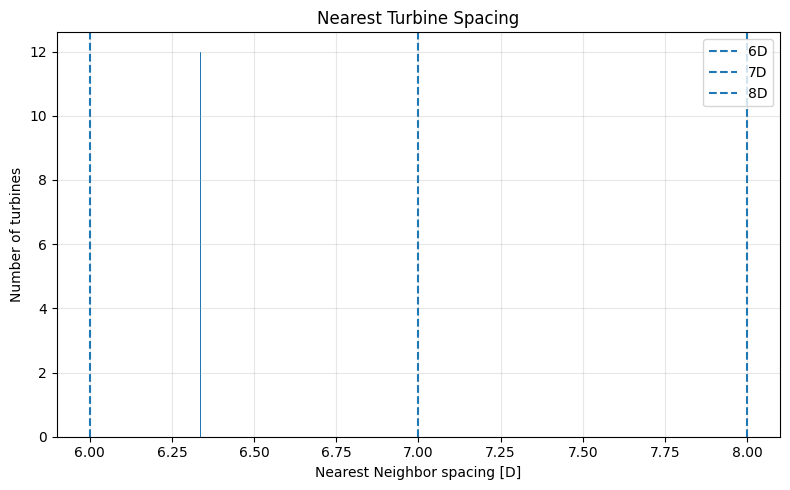

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(nearest_df['distance_D'], bins=15)
plt.axvline(6, linestyle='--', label = '6D')
plt.axvline(7, linestyle='--', label = '7D')
plt.axvline(8, linestyle='--', label = '8D')

plt.xlabel('Nearest Neighbor spacing [D]')
plt.ylabel('Number of turbines')
plt.title('Nearest Turbine Spacing')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Step 1.3: Nearest neighbor map


In [14]:
# Compute nearest neighbor of each wind turbine

nearest_pairs = []

for t in layout_df['turbine']:
    subset = dist_df[
        (dist_df['turbine_1'] == t) | (dist_df['turbine_2'] == t) 
    ]

    nearest = subset.loc[subset['distance_m'].idxmin()]

    if nearest['turbine_1'] == t:
        neighbor = nearest['turbine_2']
    else:
        neighbor = nearest['turbine_1']

    nearest_pairs.append({
        'turbine': t,
        'neighbor': neighbor,
        'distance_m': nearest['distance_m']
    })


nearest_map = pd.DataFrame(nearest_pairs)
nearest_map.head()

,turbine,neighbor,distance_m
0,A1,A2,177.447577
1,A2,A3,177.423132
2,A3,A2,177.423132
3,A4,A5,177.445022
4,A5,A6,177.432800


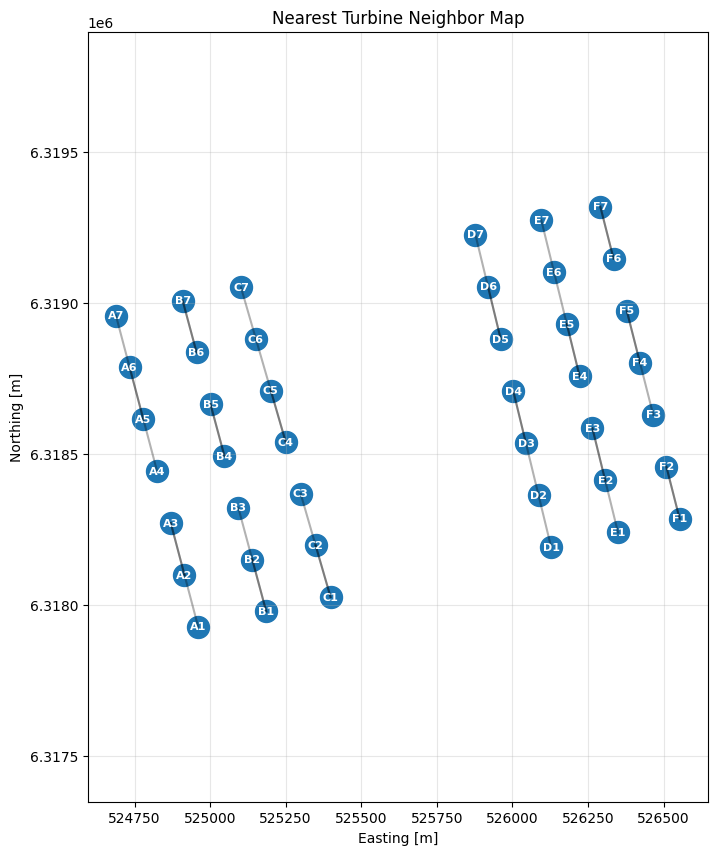

In [ ]:
plt.figure(figsize=(8,10))

plt.scatter(layout_df["x"], layout_df["y"], s=250)

for _, r in layout_df.iterrows():
    plt.text(
        r["x"], r["y"], r["turbine"],
        ha="center", va="center",
        color="white", fontsize=8, weight="bold"
    )

for _, r in nearest_map.iterrows():

    t1 = layout_df[layout_df["turbine"] == r["turbine"]].iloc[0]
    t2 = layout_df[layout_df["turbine"] == r["neighbor"]].iloc[0]

    plt.plot(
        [t1["x"], t2["x"]],
        [t1["y"], t2["y"]],
        color="black",
        alpha=0.3
    )

plt.title("Nearest Turbine Neighbor Map")
plt.xlabel("Easting [m]")
plt.ylabel("Northing [m]")
plt.axis("equal")
plt.grid(alpha=0.3)

plt.savefig('../figures/sprint3_wf_nearest_neighbor.png', dpi=300)
plt.show()

## Step 2: Wind direction statistics
We want to answer following questions
1. From which direction does the wind most often come?
2. Which mast direction signal is cleaner/more complete?
3. Which wind sectors are dominant and therefore most relevant for wake analysis?


In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("data\norre_m2_all.nc", engine="netcdf4")

[v for v in ds.data_vars if v.startswith("d3") and "_" in v and not v.endswith("_qc")]

['d31_1', 'd34_2', 'd3_pow', 'd3_wsn', 'd3_ym']

In [17]:
wd_df = ds[["d31_1", "d34_2"]].to_dataframe().reset_index()
wd_df = ds[["d31_1", "d34_2"]].to_dataframe().reset_index()

wd_df.head()
wd_df[["d31_1", "d34_2"]].describe()

,d31_1,d34_2
count,24382.000000,24382.000000
mean,209.890115,210.586573
std,82.565263,72.709022
min,0.030000,0.080000
25%,166.255000,187.892500
50%,237.265000,221.470000
75%,269.910000,259.457500
max,359.880000,359.980000


In [18]:
wd_df[["d31_1", "d34_2"]].notna().sum()

d31_1    24382
d34_2    24382
dtype: int64

In [19]:
wd_df = ds[["d31_1", "d34_2"]].to_dataframe().reset_index()

# keep rows where at least one direction signal exists
wd_df = wd_df.dropna(subset=["d31_1", "d34_2"], how="all")

# remove impossible values
for col in ["d31_1", "d34_2"]:
    wd_df.loc[(wd_df[col] < 0) | (wd_df[col] > 360), col] = np.nan

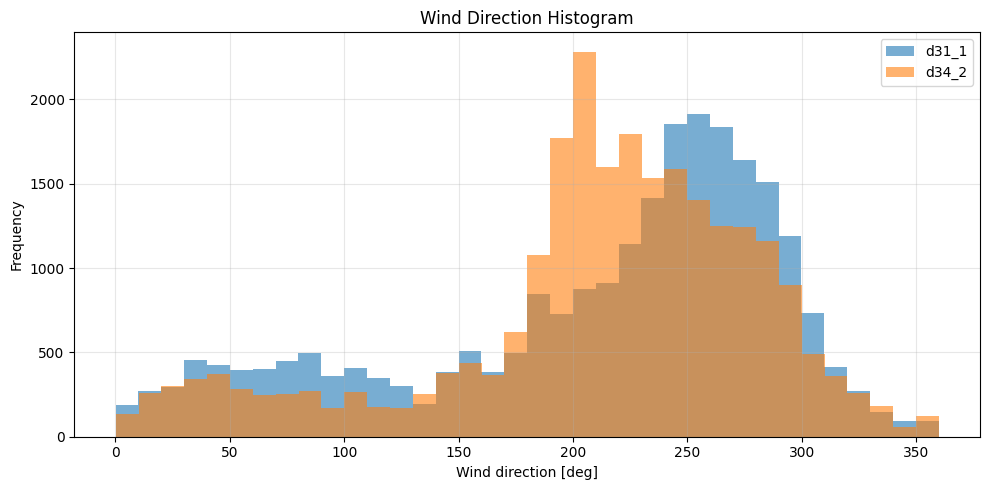

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(wd_df["d31_1"].dropna(), bins=36, alpha=0.6, label="d31_1")
plt.hist(wd_df["d34_2"].dropna(), bins=36, alpha=0.6, label="d34_2")

plt.xlabel("Wind direction [deg]")
plt.ylabel("Frequency")
plt.title("Wind Direction Histogram")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../figures/sprint3_wind_direction_masts.png', dpi=300)
plt.show()

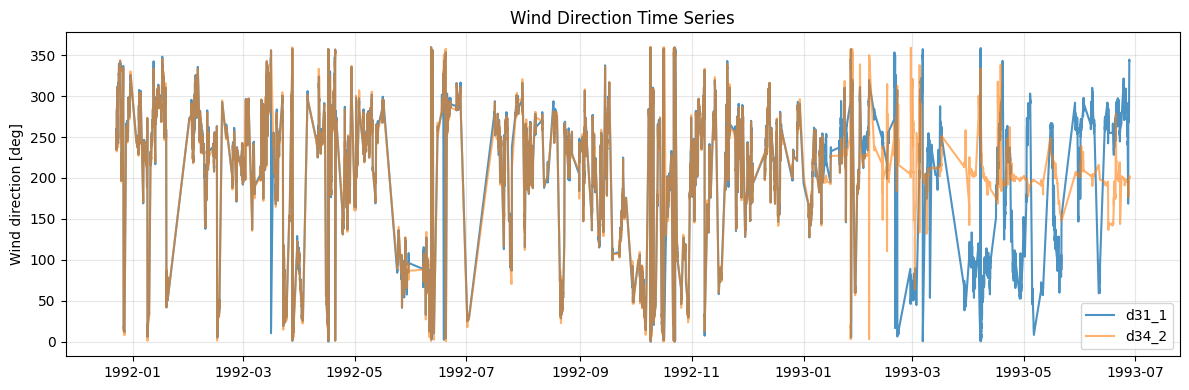

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(wd_df["time"], wd_df["d31_1"], label="d31_1", alpha=0.8)
plt.plot(wd_df["time"], wd_df["d34_2"], label="d34_2", alpha=0.6)

plt.ylabel("Wind direction [deg]")
plt.title("Wind Direction Time Series")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../figures/sprint3_wind_direction_times_series.png', dpi=300)
plt.show()

- Wind direction history from both wind masts lineups almost perfectly for most of the time, except part at the end
- It might happen because of
    - Sensor degraded
    - Mast shadow/obstruction
    - Data logging issue

In [22]:
wd_compare = wd_df.dropna(subset=["d31_1", "d34_2"]).copy()

wd_compare["diff_raw"] = wd_compare["d31_1"] - wd_compare["d34_2"]
wd_compare["diff_wrap"] = (wd_compare["diff_raw"] + 180) % 360 - 180

wd_compare["diff_wrap"].describe()

count    24382.000000
mean         2.876669
std         39.185746
min       -179.730000
25%         -0.710000
50%          1.320000
75%          3.820000
max        179.820000
Name: diff_wrap, dtype: float64

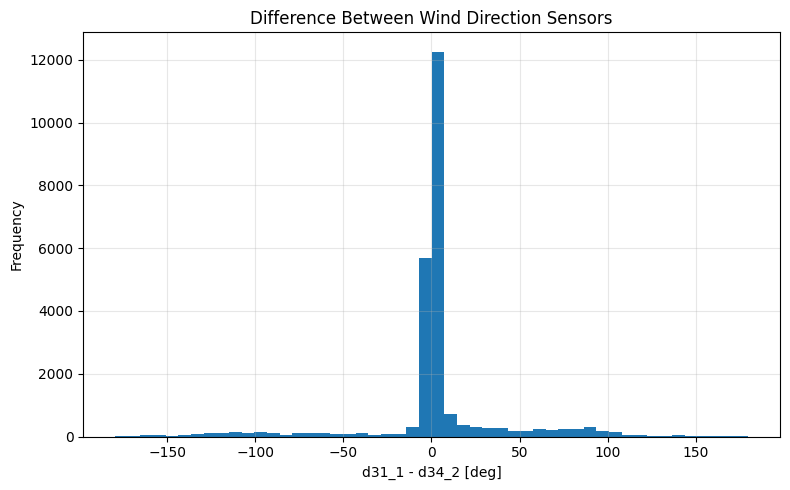

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(wd_compare["diff_wrap"], bins=50)

plt.xlabel("d31_1 - d34_2 [deg]")
plt.ylabel("Frequency")
plt.title("Difference Between Wind Direction Sensors")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../figures/sprint3_wf_difference_between_masts', dpi=300)
plt.show()

- Very strong peak around 0 deg
    - So most of the time, both sensor measure the same direction
- Narrow central cluster
- Some long tails


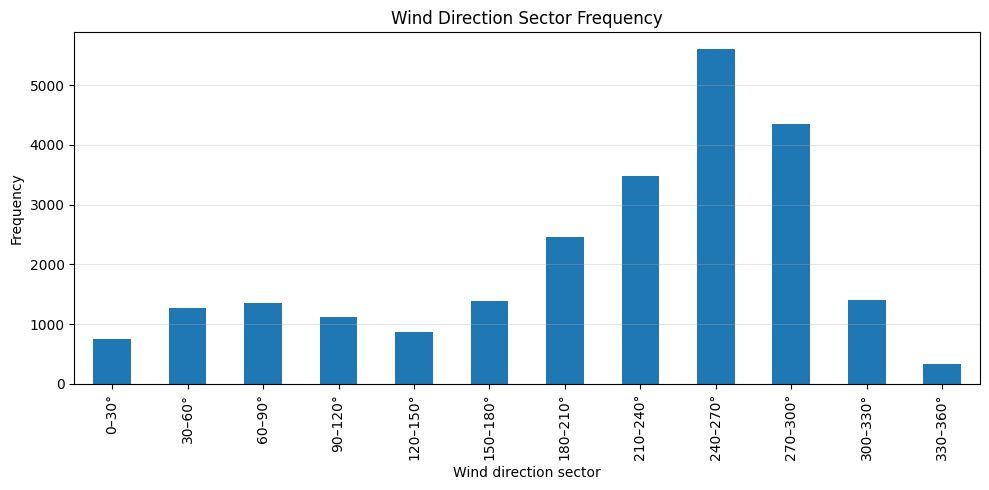

d31_1
240–270°    5602
270–300°    4342
210–240°    3478
180–210°    2452
300–330°    1413
Name: count, dtype: int64

In [ ]:
wd_ref = wd_df["d31_1"].dropna()

sector_edges = np.arange(0, 361, 30)
sector_labels = [f"{sector_edges[i]}–{sector_edges[i+1]}°" for i in range(len(sector_edges)-1)]

wd_sector = pd.cut(
    wd_ref,
    bins=sector_edges,
    labels=sector_labels,
    include_lowest=True,
    right=False
)

sector_freq = wd_sector.value_counts().sort_index()

plt.figure(figsize=(10,5))
sector_freq.plot(kind="bar")

plt.xlabel("Wind direction sector")
plt.ylabel("Frequency")
plt.title("Wind Direction Sector Frequency")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()

plt.savefig('../figures/sprint3_wind_dir_sect_freq', dpi=300)
plt.show()

sector_freq.sort_values(ascending=False).head(5)

Dominant sectors are:
- 240-270 deg 
- 270-300 deg
- 210-240 deg

So wind climate is dominated by Southwest -> West -> Northwest winds (Expected due to location of wind farm being in the north of Denamrk and wind from North sea)

### 2.2 Wind rose

In [25]:
from windrose import WindroseAxes

# Prepare wind direction and wind speed data
rose_df = ds[['d34_2', 's31_1']].to_dataframe().reset_index()
rose_df = rose_df.dropna(subset=['d34_2', 's31_1'])

# Keeping only valid ranges
rose_df = rose_df[(rose_df['d34_2'] >= 0) & rose_df['d34_2'] <=360]
rose_df = rose_df[rose_df['s31_1'] >=1]

rose_df.head()

,time,d34_2,s31_1
0,1991-12-22 23:36:00,253.61,10.61
1,1991-12-22 23:46:00,255.78,10.69
2,1991-12-22 23:56:00,257.12,9.91
3,1991-12-23 00:06:00,254.12,10.85
4,1991-12-23 00:16:00,252.15,11.18


C:\Users\szczy\AppData\Local\Temp\ipykernel_19940\2249177826.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


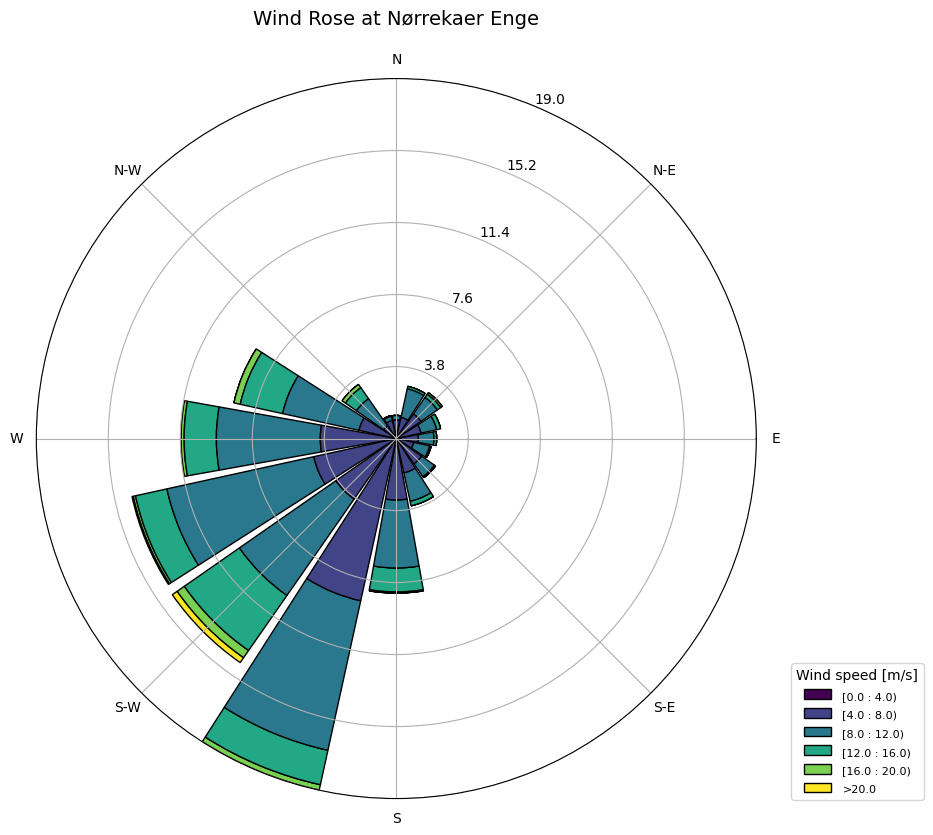

In [ ]:
fig = plt.figure(figsize=(9, 9))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    rose_df["d34_2"],
    rose_df["s31_1"],
    normed=True,
    opening=0.9,
    edgecolor="black",
    bins=[0, 4, 8, 12, 16, 20]
)

ax.set_title("Wind Rose at Nørrekaer Enge", fontsize=14, pad=20)
ax.set_legend(title="Wind speed [m/s]", loc="lower left", bbox_to_anchor=(1.05, 0))

plt.savefig('../figures/sprint3_wind_rose.png', dpi=300)
plt.tight_layout()
plt.show()

- Strongest petals are clearly in:
    - 210-240
    - 240-270
    - 270-300
- So the main inflow is South-West - West
- Which matches:
    - Sector histogram
    - expected wind climate in Denmark
    - North Atlantic storm track

## Step 3: Upstream/Downstream turbine detection

Goal:
- For given wind direction we want to determine:
    - Which turbines are upstream
    - Which turbines are downstream
    - How turbines align along the wind

**Key theory**

- A upsteam turbine means that wind reaches it earlier, downstream turbine sit further along the wind path.
- So we need to find a way to turn:
    - Turbine coordinates (x,y), wind direction $\theta$
    - Into an ordering along the wind

**Intuition of projection**

If we shine a light along the wind direction and look where each wind turbine falls on that line.

Each turbine get a single number: **projection**
- Smaller projection -> more upstream
- Larger projection -> more downstream

**Wind direction**

Meteorological wind direction, is the direction the wind comes from, but for projection we need direction the wind blows toward.

So if wind direction is:
- 250 deg
    - Flow goes toward 250+180 -> 430 deg -> 70 deg
    - So flow direction = (wind from + 180) % 360

Steps plan
1. Build relative turbine coordinates
2. Choose one example wind direction
3. Convert wind direction to flow vector
4. Project turbines onto that vector
5. Sort turbines upstream ----> downstream
6. Plot alignment map
7. Build upstream/downstream relationship




In [27]:
layout_rel = layout_df.copy()

layout_rel['x_rel'] = layout_rel['x'] - layout_rel['x'].min()
layout_rel['y_rel'] = layout_rel['y'] - layout_rel['y'].min()

layout_rel.head()

,x,y,turbine,x_rel,y_rel
0,524960.60,6317928.53,A1,271.93,0.00
1,524915.27,6318100.09,A2,226.60,171.56
2,524869.96,6318271.63,A3,181.29,343.10
3,524824.63,6318443.19,A4,135.96,514.66
4,524779.31,6318614.75,A5,90.64,686.22


Since the UTM coords are large and a bit awkward for geometry plotting, by substracting the minimum we keep the same geometry but make original local to the farm.

So coordinates are much easired to interpret.

In [28]:
# Using the most dominant direction first
wind_dir_deg = 250 # Wind comes from 250
flow_dir_deg = wind_dir_deg + 180 - 360
# If wind dir = 250, then it has flow dir of 70 deg
flow_dir_deg

70

Now to built flow-direction vector.

- In meteorology :
    - 0 = North, 90 = East
- In cartesian math :
    - x = East-West
    - y = North-South

So following transformation is made

In [29]:
theta = np.radians(flow_dir_deg)

ux = np.sin(theta)
uy = np.cos(theta)

print('Flow unit vector: ', (ux,uy))

Flow unit vector:  (np.float64(0.9396926207859083), np.float64(0.3420201433256688))


**Why sin and cos**

Because meteorological angles are measured from North, clockwise

That means:
- East component = sin($\theta$)
- North component = cos($\theta$)

If flow is 0 deg (towards North):
- ux = 0
- uy = 1

If flow is 90 deg (towards east):
- ux = 0
- uy = 1

Now to compute projection

Projection of turbine onto the flow vector:
$$p = x * u_x + y * u_y$$

In [30]:
layout_rel['projection'] = (
    layout_rel['x_rel'] * ux + 
    layout_rel['y_rel'] * uy
)

layout_rel[['turbine', 'x_rel', 'y_rel', 'projection']].head()

,turbine,x_rel,y_rel,projection
0,A1,271.93,0.00,255.530614
1,A2,226.60,171.56,271.611324
2,A3,181.29,343.10,287.703986
3,A4,135.96,514.66,303.784696
4,A5,90.64,686.22,319.874802


We convert each turbines 2D position into one scalar value along the wind axis

**Sort turbines upstream and downstream**


In [31]:
alignment_df = layout_rel.sort_values('projection').reset_index(drop=True)

alignment_df[['turbine', 'projection']].head(15)

,turbine,projection
0,A1,255.530614
1,A2,271.611324
2,A3,287.703986
3,A4,303.784696
4,A5,319.874802
5,A6,335.970885
6,A7,352.048174
7,B1,484.376153
8,B2,499.693949
9,B3,515.002348


Interpretation:
- top of table = most upstream
- bottom of table = most downstream

This gives global ordering across the whole windfarm

Although it is usefull, it is not enough by itself, because turbines in different lateral positions are not necessarily in the same wake.

So after this, we also need a **crosswind coordinate** to identify number of turbines that sit in similar wind-aligned lanes.

**Compute crosswind coordinate**

We already have $(u_x, u_y)$ a wind direction unit vector.

A perpendicular vector is:
$(-u_y, u_x)$

This gives the cross-wind diretion

In [32]:
vx = -uy
vy = ux

layout_rel['crosswind'] = (
    layout_rel['x_rel'] * vx +
    layout_rel['y_rel'] * vy
)

layout_rel[['turbine', 'projection', 'crosswind']].head()

,turbine,projection,crosswind
0,A1,255.530614,-93.005538
1,A2,271.611324,83.711902
2,A3,287.703986,260.403706
3,A4,303.784696,437.121146
4,A5,319.874802,613.835164


**What this means**

Now turbine has two coordinates in the wind-based reference frame
- Projection = along-wind position
- Crosswind = sideways positionb

This allows to identify turbines that are:
- far apart along wind -> possible up/down stream
- close sideways -> likely in the same wake lane

**Plot turbine allignment map**

<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
C:\Users\szczy\AppData\Local\Temp\ipykernel_19940\867026170.py:38: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'Turbine Alignment map for wind direction {wind_dir_deg}$^\circ$')


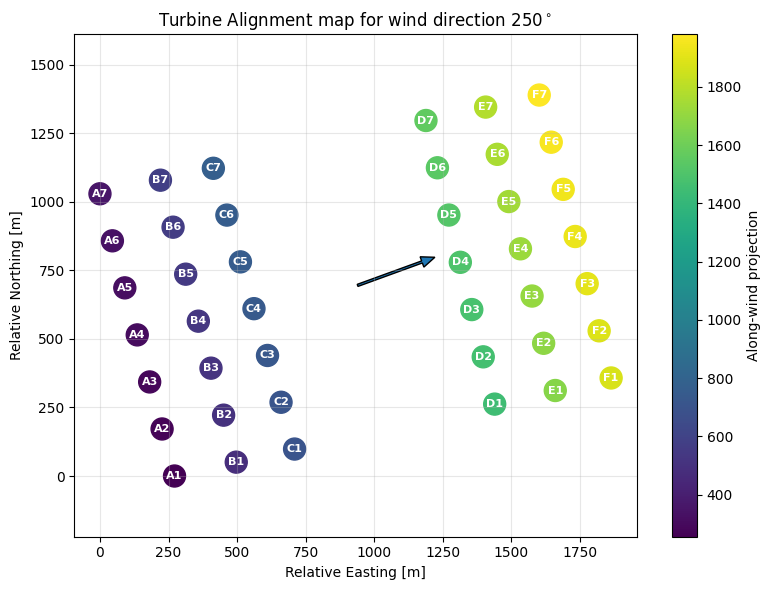

In [ ]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    layout_rel['x_rel'],
    layout_rel['y_rel'], 
    c = layout_rel['projection'],
    s=250
)

for _,r in layout_rel.iterrows():
    plt.text(
        r['x_rel'],
        r['y_rel'],
        r['turbine'],
        ha='center',
        va='center',
        color = 'white',
        fontsize = 8,
        weight = 'bold'
    )

# Add flow arrow
x0 = layout_rel['x_rel'].mean()
y0 = layout_rel['y_rel'].mean()
arrow_scale = 300

plt.arrow(
    x0,y0,
    arrow_scale * ux,
    arrow_scale * uy,
    width = 8,
    head_width = 40,
    head_length = 50,
    length_includes_head = True
)

plt.colorbar(sc, label='Along-wind projection')
plt.title(f'Turbine Alignment map for wind direction {wind_dir_deg}$^\circ$')
plt.xlabel('Relative Easting [m]')
plt.ylabel('Relative Northing [m]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../figures/sprint3_turbine_alignment_map.png', dpi=300)
plt.show()

**Inspect upstream/downstream order**

This gives basic ordering.

But again, global ordering alone is not enough for actual wake chains, because wind turbines need to be near eachother in crosswind position too.

In [34]:
alignment_df = layout_rel.sort_values('projection').reset_index(drop=True)

alignment_df[['turbine', 'projection', 'crosswind']]

,turbine,projection,crosswind
0,A1,255.530614,-93.005538
1,A2,271.611324,83.711902
2,A3,287.703986,260.403706
3,A4,303.784696,437.121146
4,A5,319.874802,613.835164
5,A6,335.970885,790.536366
6,A7,352.048174,967.244408
7,B1,484.376153,-122.493674
8,B2,499.693949,54.320533
9,B3,515.002348,231.138160


**Build candidate upstream/downstream relationships**

We want to define possible upstream/downstream pairs

A practical rule is:
- Candidate downstream turbines should have larger projection
- and small crosswind difference

We'll compare every pair and keep only pairs where:
- downstream is farther along wind
- lateral seperation is small enough

In [35]:
# Starting with simple threshold

crosswind_threshold = 120 # meters, can be tuned later

relationships = []

for (i, row1), (j, row2) in combinations(layout_rel.iterrows(), 2):
    
    proj_diff = row2['projection'] - row1['projection']
    cross_diff = abs(row2['crosswind'] - row1['crosswind'])

    # row1 upstream of row2
    if proj_diff > 0 and cross_diff <= crosswind_threshold:
        relationships.append({
            'upstream': row1['turbine'],
            'downstream': row2['turbine'],
            'proj_diff': proj_diff,
            'cross_diff': cross_diff
        })

    # or row2 upstream of row1
    elif proj_diff < 0 and cross_diff <= crosswind_threshold:
        relationships.append({
            'upstream': row2['turbine'],
            'downstream': row1['turbine'],
            'proj_diff': abs(proj_diff),
            'cross_diff': cross_diff
        })

relationships_df = pd.DataFrame(relationships)
relationships_df.sort_values(['cross_diff', 'proj_diff']).head(20)

,upstream,downstream,proj_diff,cross_diff
36,B1,F2,1407.498015,2.556871
40,B2,F3,1409.936275,2.816460
44,B3,F4,1412.402727,3.086310
48,B4,F5,1414.856361,3.362137
52,B5,F6,1417.298041,3.612329
56,B6,F7,1419.751675,3.888156
4,A1,E2,1430.645959,5.533444
9,A2,E3,1433.739482,5.893186
14,A3,E4,1436.802258,6.220454
19,A4,E5,1439.873567,6.582752


**Theory behind this threshold**

A wake mostly affects turbines that are:
- Roughly behind each other in wind direction
- not too far offset sideways

So *crosswind_threshold* acts like simple-wake lane filter.

We'll tune it later using rotor diameter
- Since rotor diameter is 28m, a threshold like 4D (112m) is sensible first choice. So 120m is a good starting point.

**Nearest downstream turbine in each wake lane**

To avoid too many pair combinations, we can choose each turbine nearest downstream candidate.

In [36]:
nearest_downstream = (
    relationships_df
    .sort_values(['upstream', 'proj_diff'])
    .groupby('upstream', as_index=False)
    .first()
)

nearest_downstream.head(20)

,upstream,downstream,proj_diff,cross_diff
0,A1,B1,228.845538,29.488136
1,A2,B2,228.082625,29.391369
2,A3,B3,227.298362,29.265547
3,A4,B4,226.526052,29.165359
4,A5,B5,225.750322,29.074569
5,A6,B6,224.966059,28.948747
6,A7,B7,224.206566,28.842582
7,B1,C1,216.239113,27.868829
8,B2,C2,212.907247,27.432978
9,B3,C3,209.575380,26.997128


Now we have explicit relationships like
- A1 - B1 
- B1 - C1
- C1 - D1
for the chosen wind direction

**Plot wake links in the wind farm**

<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
C:\Users\szczy\AppData\Local\Temp\ipykernel_19940\92728266.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'Upstream/Downstream relationships for wind direction {wind_dir_deg}$^\circ$')


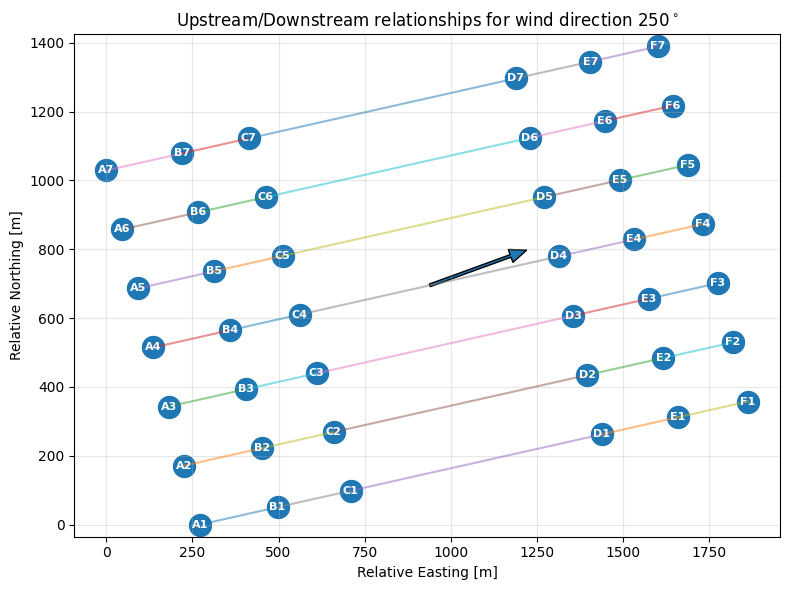

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(layout_rel['x_rel'], layout_rel['y_rel'], s=250)

for _,r in layout_rel.iterrows():
    plt.text(
        r['x_rel'], r['y_rel'], r['turbine'],
        ha='center', va='center',
        color = 'white', fontsize=8, weight='bold'
    )

for _,r in nearest_downstream.iterrows():
    up = layout_rel[layout_rel['turbine'] == r['upstream']].iloc[0]
    dn = layout_rel[layout_rel['turbine'] == r['downstream']].iloc[0]

    plt.plot(
        [up['x_rel'], dn['x_rel']],
        [up['y_rel'], dn['y_rel']],
        alpha = 0.5
    )

# FLow arrow
x0 = layout_rel['x_rel'].mean()
y0 = layout_rel['y_rel'].mean()
arrow_scale = 300

plt.arrow(
    x0,y0,
    arrow_scale * ux,
    arrow_scale * uy,
    width = 8,
    head_width = 40,
    head_length = 50,
    length_includes_head = True
)

plt.title(f'Upstream/Downstream relationships for wind direction {wind_dir_deg}$^\circ$')
plt.xlabel('Relative Easting [m]')
plt.ylabel('Relative Northing [m]')
plt.axis("equal")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../figures/sprint3_up_down_pairs.png', dpi=300)
plt.show()

Main conclusions we can take out from the results are:
- Turbine alignment map:
    - Gradient is going in expected way, showing wind flow SW -> NE.
    - As expected from the wind rose
    - Visually confirmed that Upstream block A-turbines, Downstream block F-turbines
- Upstream/Downstream relationship map
    - Wake lanes follow the turbine rows exactly as expected
    - Confirming farm layout + wind direction -> wake chains are predictable
- Relationship table
    - Example A1 -> B1 = 229m
    - In rotor diameters 229/28 = 8.2D
    - Fitting documentation where spacing was given as 7-8D 
    - Crosswind seperation = 29D ~ 1D

**Wind-aligned coordinate plot**

Idea is that we rotate coordinate system so that:
- y-axis -> along the wind direction
- x-axis -> perpendicular to the wind
- So each turbine becomes (crosswind,projection)

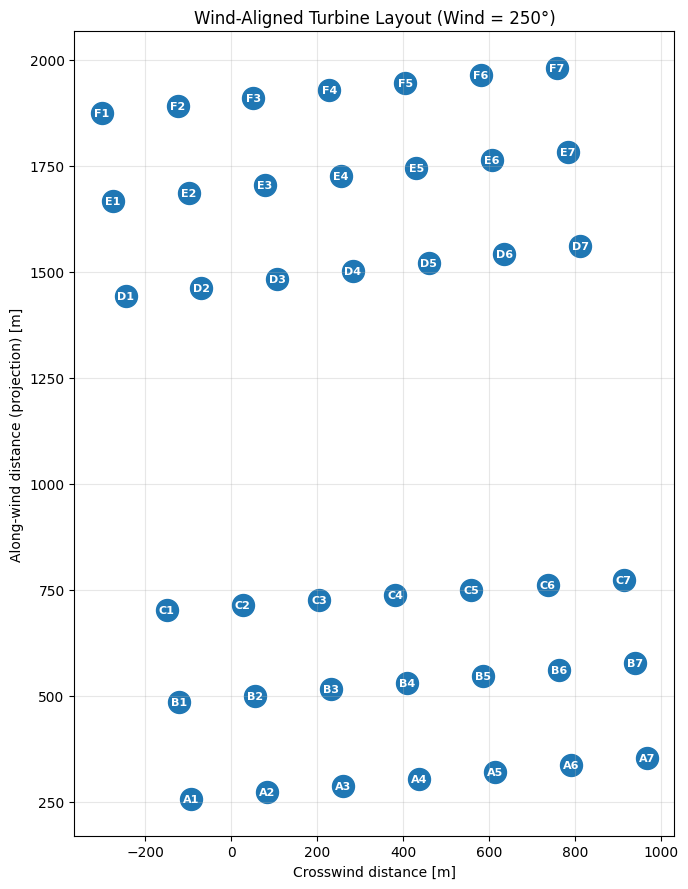

In [38]:
plt.figure(figsize=(7,9))

plt.scatter(
    layout_rel["crosswind"],
    layout_rel["projection"],
    s=250
)

for _, r in layout_rel.iterrows():
    plt.text(
        r["crosswind"],
        r["projection"],
        r["turbine"],
        ha="center",
        va="center",
        color="white",
        fontsize=8,
        weight="bold"
    )

plt.xlabel("Crosswind distance [m]")
plt.ylabel("Along-wind distance (projection) [m]")
plt.title(f"Wind-Aligned Turbine Layout (Wind = {wind_dir_deg}°)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Wake loss analysis


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

ds = xr.open_dataset('data\norre_m2_all.nc')

df = ds.to_dataframe().reset_index()
print(df.shape)
df.head()

(72577, 261)


,time,connect,connect_qc,d31_1,d31_1_qc,d34_2,d34_2_qc,park,park_qc,s31_1,...,f6_wsn,f6_wsn_qc,f6_ym,f6_ym_qc,f7_pow,f7_pow_qc,f7_wsn,f7_wsn_qc,f7_ym,f7_ym_qc
0,1991-12-22 23:36:00,42.0,0,257.41,0.0,253.61,0.0,5253.5,0,10.61,...,NaN,NaN,-10.71,0.0,113.5,0.0,NaN,NaN,-9.38,0.0
1,1991-12-22 23:46:00,42.0,0,259.57,0.0,255.78,0.0,5012.9,0,10.69,...,NaN,NaN,-4.01,0.0,98.9,0.0,NaN,NaN,-9.68,0.0
2,1991-12-22 23:56:00,42.0,0,260.11,0.0,257.12,0.0,4272.9,0,9.91,...,NaN,NaN,-3.73,0.0,78.6,0.0,NaN,NaN,-5.21,0.0
3,1991-12-23 00:06:00,42.0,0,255.64,0.0,254.12,0.0,5253.9,0,10.85,...,NaN,NaN,-6.03,0.0,113.8,0.0,NaN,NaN,-8.50,0.0
4,1991-12-23 00:16:00,42.0,0,252.99,0.0,252.15,0.0,5740.6,0,11.18,...,NaN,NaN,-6.13,0.0,128.9,0.0,NaN,NaN,-5.75,0.0


### 4.1 Selecting wind signal

Since both of them agree pretty well, we choose d31_1

In [40]:
df['wind_dir'] = df['d31_1']

# Select dominant wind sector
# Around 240-270 deg

sector = (df['wind_dir'] >= 240) & (df['wind_dir'] <= 270)
df_sector = df[sector]
print('Samples in sector:', len(df_sector))

power_cols = [c for c in df.columns if c.endswith("_pow")]
print(power_cols)
print("Number of power columns:", len(power_cols))


Samples in sector: 5603
['a2_pow', 'a3_pow', 'a4_pow', 'a5_pow', 'a6_pow', 'a7_pow', 'b1_pow', 'b2_pow', 'b3_pow', 'b4_pow', 'b5_pow', 'b6_pow', 'b7_pow', 'c1_pow', 'c2_pow', 'c3_pow', 'c4_pow', 'c5_pow', 'c6_pow', 'c7_pow', 'd1_pow', 'd2_pow', 'd3_pow', 'd4_pow', 'd5_pow', 'd6_pow', 'd7_pow', 'e1_pow', 'e2_pow', 'e3_pow', 'e4_pow', 'e5_pow', 'e6_pow', 'e7_pow', 'f1_pow', 'f2_pow', 'f3_pow', 'f4_pow', 'f5_pow', 'f7_pow']
Number of power columns: 40


### 4.2 Select turbine pair
- Starting with a first pair from Step 3 (A2 upstream-B2 downstream) since A1 has a missing power signal

In [41]:
P_up = df_sector['a2_pow']
P_down = df_sector['b2_pow']

### 4.3 Remove invalid data
- NaNs
- Zero upstream production


In [42]:
valid = (P_up > 0) & (~P_up.isna()) & (~P_down.isna())

P_up = P_up[valid]
P_down = P_down[valid]

### 4.4 Compute power ratio

Wake effect metric 
$ \mathrm{Power\_ ratio} = \mathrm{P\_ downstream} / \mathrm{P\_ upstream}$

In [43]:
power_ratio = P_down / P_up
wake_loss = 1 - power_ratio
print('Mean power ratio:', power_ratio.mean())
print('Median power ration:', power_ratio.median())
print('Mean wake loss:', wake_loss.mean())

Mean power ratio: 0.9135138500455611
Median power ration: 0.919887353746577
Mean wake loss: 0.08648614995443904


### 4.5 Plot upstream vs downstream power

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
C:\Users\szczy\AppData\Local\Temp\ipykernel_19940\1085427296.py:9: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Wake effect: B2 vs A2 (240-270$^\circ$ sector)')


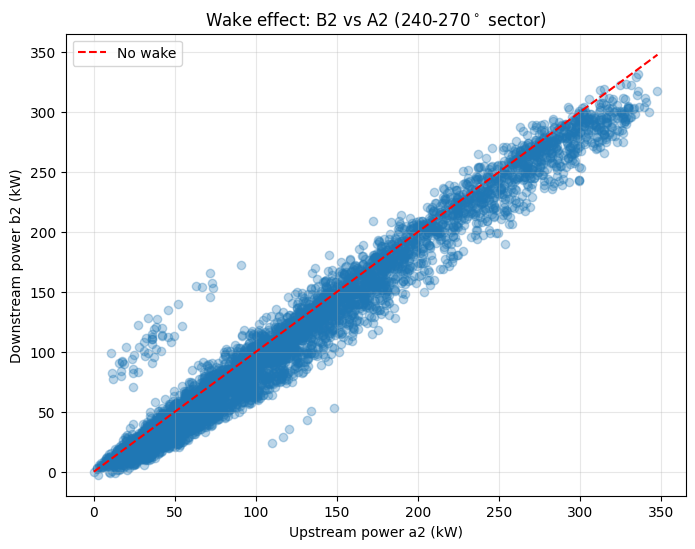

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(P_up, P_down, alpha=.3)

max_p = max(P_up.max(), P_down.max())
plt.plot([0,max_p], [0, max_p], 'r--', label='No wake')

plt.xlabel('Upstream power a2 (kW)')
plt.ylabel('Downstream power b2 (kW)')
plt.title('Wake effect: B2 vs A2 (240-270$^\circ$ sector)')
plt.legend()
plt.grid(alpha=.3)

plt.savefig('../figures/sprint3_wake_effects_b2_vs_a2.png', dpi=300)
plt.show()

- Red line represents where: Downstream = Upstream (meaning no wake effecets)
- Most of the points are below it, meaning that B2 is losing power becase of A2's wake
- Higher upstream power effect increases
    - Stronger wind
    - Stronger wake deficit
    - Turbines operate closer to rated region
    - So wake becomes more visible
- Some points are although above the line, because of:
    - Turbulence
    - Slight wind direction shifts
    - Measurement noise
    - Control system differences
    - Normal in wind SCADA data

### 4.6 Histogram of power ratio

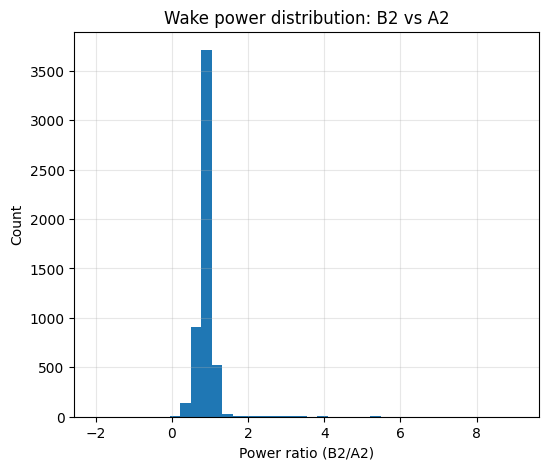

In [ ]:
plt.figure(figsize=(6,5))
plt.hist(power_ratio, bins=40)

plt.xlabel('Power ratio (B2/A2)')
plt.ylabel('Count')
plt.title('Wake power distribution: B2 vs A2')
plt.grid(alpha=.3)

plt.savefig('../figures/sprint3_wake_power_distr_b2_vs_a2.png', dpi=300)
plt.show()

### 4.7 Wake chain analysis

Since we did calculations for 1 pair, we need to expand it into full chain, so B2->A2, B2->C2, C2-> D2, D2->E2, E2->F2


**We need to focus on turbine pairs that have available data, we can update the wake chains**

In [46]:
chains = [
    ["a2", "b2", "c2", "d2", "e2", "f2"],
    ["a3", "b3", "c3", "d3", "e3", "f3"],
    ["a4", "b4", "c4", "d4", "e4", "f4"],
]

In [47]:
chain = chains[1]

ratios = []
labels = []

for i in range(len(chain)-1):
    up = df_sector[f'{chain[i]}_pow']
    down = df_sector[f'{chain[i+1]}_pow']

    valid = (~up.isna() & ~down.isna()) & (up > 0)

    ratio = (down[valid] / up[valid]).mean()

    ratios.append(ratio)
    labels.append(f'{chain[i+1].upper()} / {chain[i].upper()}')

print(labels)
print(ratios)

['B3 / A3', 'C3 / B3', 'D3 / C3', 'E3 / D3', 'F3 / E3']
[np.float64(1.0346047387353283), np.float64(0.94392697637133), np.float64(7.134372768864648), np.float64(1.0120763066829286), np.float64(0.8636790285735524)]


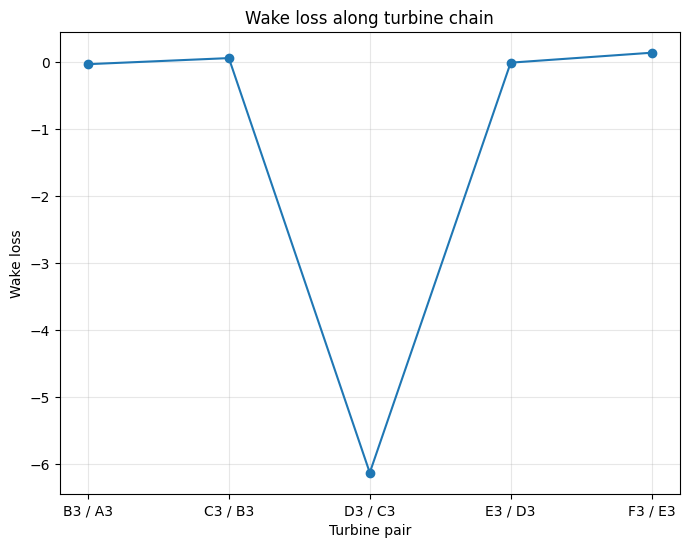

In [ ]:
wake_loss = [1-r for r in ratios]

plt.figure(figsize=(8,6))
plt.plot(labels,wake_loss,marker='o')

plt.ylabel('Wake loss')
plt.xlabel('Turbine pair')
plt.title('Wake loss along turbine chain')

plt.grid(alpha=.3)

plt.savefig('../figures/sprint3_wake_loss_along_chain.png', dpi=300)
plt.show()

Here can be seen that something is wrong with calculations.

Wake loss of -6 would mean the downstream turbine produces 6x more power which is physically impossible. 

So we need to tighten the analysis.

**Problem 1- Wind speed regime mixing**

Right now we compare all wind speeds, which breaks analysis because:
- At very low wind speeds, turbine produces near-zero power -> ratios explode
- Near rated turbines saturate -> ratios become misleading

Professionally we restrict analysis to the linear power curve region.

For this turbine (~350 kW max), a good band is roughly: *5/10 m/s*

In [49]:
[c for c in df.columns if "s31" in c.lower() or "speed" in c.lower() or "ws" in c.lower()]

['s31_1',
 's31_1_qc',
 's31_2',
 's31_2_qc',
 'a1_wsn',
 'a1_wsn_qc',
 'a2_wsn',
 'a2_wsn_qc',
 'a3_wsn',
 'a3_wsn_qc',
 'a4_wsn',
 'a4_wsn_qc',
 'a5_wsn',
 'a5_wsn_qc',
 'a6_wsn',
 'a6_wsn_qc',
 'a7_wsn',
 'a7_wsn_qc',
 'b1_wsn',
 'b1_wsn_qc',
 'b2_wsn',
 'b2_wsn_qc',
 'b3_wsn',
 'b3_wsn_qc',
 'b4_wsn',
 'b4_wsn_qc',
 'b5_wsn',
 'b5_wsn_qc',
 'b6_wsn',
 'b6_wsn_qc',
 'b7_wsn',
 'b7_wsn_qc',
 'c1_wsn',
 'c1_wsn_qc',
 'c2_wsn',
 'c2_wsn_qc',
 'c3_wsn',
 'c3_wsn_qc',
 'c4_wsn',
 'c4_wsn_qc',
 'c5_wsn',
 'c5_wsn_qc',
 'c6_wsn',
 'c6_wsn_qc',
 'c7_wsn',
 'c7_wsn_qc',
 'd1_wsn',
 'd1_wsn_qc',
 'd2_wsn',
 'd2_wsn_qc',
 'd3_wsn',
 'd3_wsn_qc',
 'd4_wsn',
 'd4_wsn_qc',
 'd5_wsn',
 'd5_wsn_qc',
 'd6_wsn',
 'd6_wsn_qc',
 'd7_wsn',
 'd7_wsn_qc',
 'e1_wsn',
 'e1_wsn_qc',
 'e2_wsn',
 'e2_wsn_qc',
 'e3_wsn',
 'e3_wsn_qc',
 'e4_wsn',
 'e4_wsn_qc',
 'e5_wsn',
 'e5_wsn_qc',
 'e6_wsn',
 'e6_wsn_qc',
 'e7_wsn',
 'e7_wsn_qc',
 'f1_wsn',
 'f1_wsn_qc',
 'f2_wsn',
 'f2_wsn_qc',
 'f3_wsn',
 'f3_wsn_qc',
 'f4

In [50]:
# --- Select inflow signals ---
df["wind_dir"] = df["d31_1"]
df["wind_speed"] = df["s31_1"].fillna(df["s31_2"])

# --- Filter to dominant wake-aligned sector and useful wind speed range ---
df_sector = df[
    (df["wind_dir"] >= 245) & (df["wind_dir"] <= 255) &
    (df["wind_speed"] >= 5) & (df["wind_speed"] <= 10)
].copy()

print("Samples after filters:", len(df_sector))

Samples after filters: 1105


Labels: ['B3 / A3', 'C3 / B3', 'D3 / C3', 'E3 / D3', 'F3 / E3']
Ratios: [np.float64(0.9409158050221565), np.float64(0.9897848902315165), np.float64(0.9422619047619047), np.float64(1.0168067226890756), np.float64(0.9080459770114943)]
Wake loss: [np.float64(0.05908419497784345), np.float64(0.010215109768483499), np.float64(0.057738095238095255), np.float64(-0.01680672268907557), np.float64(0.09195402298850575)]


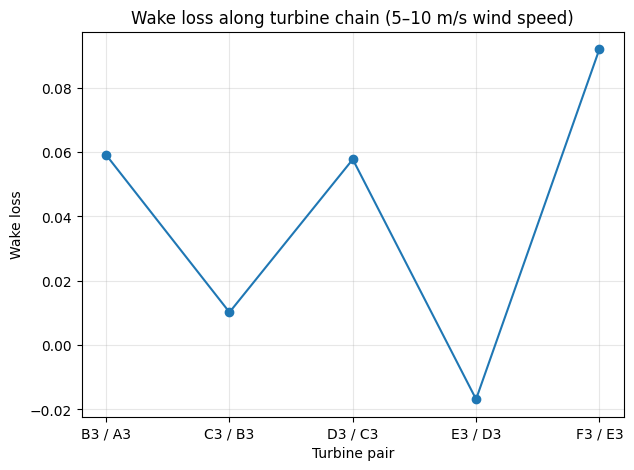

In [ ]:
chain = ["a3", "b3", "c3", "d3", "e3", "f3"]

ratios = []
labels = []

for i in range(len(chain) - 1):
    up = df_sector[f"{chain[i]}_pow"]
    down = df_sector[f"{chain[i+1]}_pow"]

    valid = (
        (~up.isna()) &
        (~down.isna()) &
        (up > 20)
    )

    ratio = down[valid] / up[valid]

    # remove unrealistic values
    ratio = ratio[(ratio > 0) & (ratio < 2)]

    ratio_median = ratio.median()

    ratios.append(ratio_median)
    labels.append(f"{chain[i+1].upper()} / {chain[i].upper()}")

print("Labels:", labels)
print("Ratios:", ratios)
print("Wake loss:", [1 - r for r in ratios])

wake_loss = [1 - r for r in ratios]

plt.figure(figsize=(7,5))

plt.plot(labels, wake_loss, marker="o")

plt.ylabel("Wake loss")
plt.xlabel("Turbine pair")
plt.title("Wake loss along turbine chain (5–10 m/s wind speed)")

plt.grid(alpha=0.3)
plt.savefig('../figures/sprint3_wf_wake_loss_chain3.png', dpi=300)
plt.show()

Wake losses were estimated for the turbine chain A3 → B3 → C3 → D3 → E3 → F3 using the median downstream-to-upstream power ratio under filtered inflow conditions:

- wind direction: 245–255°
- wind speed: 5–10 m/s

Results indicate generally modest wake losses, mostly in the range of 1–9%, with the largest loss observed for F3 / E3. One pair (E3 / D3) showed a slightly negative wake loss, which is likely caused by turbulence, wake recovery, directional variability, or SCADA noise rather than a true performance gain.

Overall, the chain confirms that wake effects are detectable in the SCADA data, but they are not uniform from pair to pair.



### 4.8 Wake chain analysis for several rows

In [52]:
chains = [
    ["a2", "b2", "c2", "d2", "e2", "f2"],
    ["a3", "b3", "c3", "d3", "e3", "f3"],
    ["a4", "b4", "c4", "d4", "e4", "f4"],
    ["a5", "b5", "c5", "d5", "e5", "f5"],
]

results = []

for chain in chains:
    row_name = chain[0][-1]   # e.g. "2", "3", "4"

    for i in range(len(chain) - 1):
        up_col = f"{chain[i]}_pow"
        down_col = f"{chain[i+1]}_pow"

        up = df_sector[up_col]
        down = df_sector[down_col]

        valid = (~up.isna()) & (~down.isna()) & (up > 20)

        ratio = down[valid] / up[valid]
        ratio = ratio[(ratio > 0) & (ratio < 2)]

        results.append({
            "row": row_name,
            "pair": f"{chain[i+1].upper()} / {chain[i].upper()}",
            "n_samples": len(ratio),
            "ratio_median": ratio.median(),
            "wake_loss": 1 - ratio.median()
        })

wake_df = pd.DataFrame(results)
wake_df

,row,pair,n_samples,ratio_median,wake_loss
0,2,B2 / A2,995,0.902357,0.097643
1,2,C2 / B2,1004,0.977718,0.022282
2,2,D2 / C2,993,0.907801,0.092199
3,2,E2 / D2,949,0.908898,0.091102
4,2,F2 / E2,908,1.013331,-0.013331
5,3,B3 / A3,921,0.940916,0.059084
6,3,C3 / B3,960,0.989785,0.010215
7,3,D3 / C3,900,0.942262,0.057738
8,3,E3 / D3,885,1.016807,-0.016807
9,3,F3 / E3,935,0.908046,0.091954


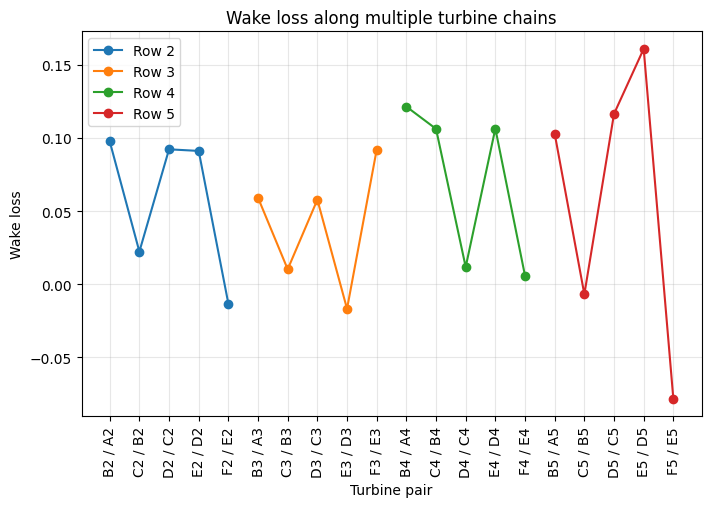

In [ ]:
plt.figure(figsize=(8,5))

for row in wake_df["row"].unique():
    subset = wake_df[wake_df["row"] == row]
    plt.plot(subset["pair"], subset["wake_loss"], marker="o", label=f"Row {row}")

plt.ylabel("Wake loss")
plt.xlabel("Turbine pair")
plt.title("Wake loss along multiple turbine chains")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=90)

plt.savefig('../figures/sprint3_wf_wake_loss_all_chains.png', dpi=300)
plt.show()

### 4.9 Wind farm wake loss heatmap

For a chosen sector and wind-speed range, we already know likely up/downstream pairs from the farm geometry.

Now we will:
- Define valid wake chains
- Compute wake loss for each downstream turbine relative to its immediate upstream neighbor
- Assign wake loss to the downstream turbine
- Place value on the farm layout
- Plot scatter map

In [54]:
coords = {
"A1": (524960.60, 6317928.53),
"A2": (524915.27, 6318100.09),
"A3": (524869.96, 6318271.63),
"A4": (524824.63, 6318443.19),
"A5": (524779.31, 6318614.75),
"A6": (524734.00, 6318786.30),
"A7": (524688.67, 6318957.85),

"B1": (525185.73, 6317979.09),
"B2": (525139.65, 6318150.48),
"B3": (525093.56, 6318321.87),
"B4": (525047.47, 6318493.26),
"B5": (525001.39, 6318664.64),
"B6": (524955.30, 6318836.04),
"B7": (524909.22, 6319007.43),

"C1": (525398.46, 6318026.86),
"C2": (525349.10, 6318197.52),
"C3": (525299.73, 6318368.18),
"C4": (525250.37, 6318538.85),
"C5": (525200.99, 6318709.50),
"C6": (525151.63, 6318880.16),
"C7": (525102.26, 6319050.83),

"D1": (526128.28, 6318190.75),
"D2": (526086.51, 6318363.15),
"D3": (526044.74, 6318535.54),
"D4": (526002.95, 6318707.92),
"D5": (525961.18, 6318880.32),
"D6": (525919.41, 6319052.71),
"D7": (525877.64, 6319225.11),

"E1": (526349.18, 6318240.36),
"E2": (526306.86, 6318412.64),
"E3": (526264.56, 6318584.92),
"E4": (526222.24, 6318757.20),
"E5": (526179.92, 6318929.47),
"E6": (526137.61, 6319101.75),
"E7": (526095.29, 6319274.03),

"F1": (526552.91, 6318286.10),
"F2": (526509.22, 6318458.08),
"F3": (526465.52, 6318630.06),
"F4": (526421.84, 6318802.04),
"F5": (526378.15, 6318974.01),
"F6": (526334.45, 6319145.99),
"F7": (526290.76, 6319317.97)
}

layout_df = pd.DataFrame.from_dict(coords, orient='index', columns=['x','y'])

layout_df.index.name = 'turbine'
layout_df = layout_df.reset_index()

layout_df['turbine'] = layout_df['turbine'].str.lower()

layout_df.head()


,turbine,x,y
0,a1,524960.60,6317928.53
1,a2,524915.27,6318100.09
2,a3,524869.96,6318271.63
3,a4,524824.63,6318443.19
4,a5,524779.31,6318614.75


**Extract downstream wind turbines from wake table**

Currently it contains:
- pair
- wake_loss
- row

We want to add downstream turbine name:

In [55]:
wake_df['downstream_turbine'] = wake_df['pair'].str.split(' / ').str[0].str.lower()
wake_df[['pair', 'downstream_turbine', 'wake_loss']].head()

,pair,downstream_turbine,wake_loss
0,B2 / A2,b2,0.097643
1,C2 / B2,c2,0.022282
2,D2 / C2,d2,0.092199
3,E2 / D2,e2,0.091102
4,F2 / E2,f2,-0.013331


**Merge wake losses with turbine layout**


In [56]:
wake_loss_by_turbine = (
    wake_df
    .groupby('downstream_turbine')['wake_loss']
    .median()
    .reset_index()
)

wake_map_df = layout_df.merge(
    wake_loss_by_turbine,
    left_on="turbine",
    right_on="downstream_turbine",
    how="left"
)
print(sorted(wake_loss_by_turbine["downstream_turbine"].unique()))
print(sorted(layout_df["turbine"].unique())[:15])
print("Number of turbines with wake values:", wake_map_df["wake_loss"].notna().sum())

['b2', 'b3', 'b4', 'b5', 'c2', 'c3', 'c4', 'c5', 'd2', 'd3', 'd4', 'd5', 'e2', 'e3', 'e4', 'e5', 'f2', 'f3', 'f4', 'f5']
['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'c1']
Number of turbines with wake values: 20


In [57]:
layout_df["turbine"] = layout_df["turbine"].str.strip().str.lower()
wake_loss_by_turbine["downstream_turbine"] = wake_loss_by_turbine["downstream_turbine"].str.strip().str.lower()

wake_map_df = layout_df.merge(
    wake_loss_by_turbine,
    left_on="turbine",
    right_on="downstream_turbine",
    how="left"
)

print("Matched turbines:", wake_map_df["wake_loss"].notna().sum())
print(wake_map_df[wake_map_df["wake_loss"].notna()].head(20))

Matched turbines: 20
   turbine          x           y downstream_turbine  wake_loss
8       b2  525139.65  6318150.48                 b2   0.097643
9       b3  525093.56  6318321.87                 b3   0.059084
10      b4  525047.47  6318493.26                 b4   0.121390
11      b5  525001.39  6318664.64                 b5   0.102902
15      c2  525349.10  6318197.52                 c2   0.022282
16      c3  525299.73  6318368.18                 c3   0.010215
17      c4  525250.37  6318538.85                 c4   0.106180
18      c5  525200.99  6318709.50                 c5  -0.006897
22      d2  526086.51  6318363.15                 d2   0.092199
23      d3  526044.74  6318535.54                 d3   0.057738
24      d4  526002.95  6318707.92                 d4   0.011788
25      d5  525961.18  6318880.32                 d5   0.116410
29      e2  526306.86  6318412.64                 e2   0.091102
30      e3  526264.56  6318584.92                 e3  -0.016807
31      e4  526222.

In [58]:
wake_map_df_valid = wake_map_df[wake_map_df["wake_loss"].notna()].copy()
wake_map_df_valid

,turbine,x,y,downstream_turbine,wake_loss
8,b2,525139.65,6318150.48,b2,0.097643
9,b3,525093.56,6318321.87,b3,0.059084
10,b4,525047.47,6318493.26,b4,0.121390
11,b5,525001.39,6318664.64,b5,0.102902
15,c2,525349.10,6318197.52,c2,0.022282
16,c3,525299.73,6318368.18,c3,0.010215
17,c4,525250.37,6318538.85,c4,0.106180
18,c5,525200.99,6318709.50,c5,-0.006897
22,d2,526086.51,6318363.15,d2,0.092199
23,d3,526044.74,6318535.54,d3,0.057738


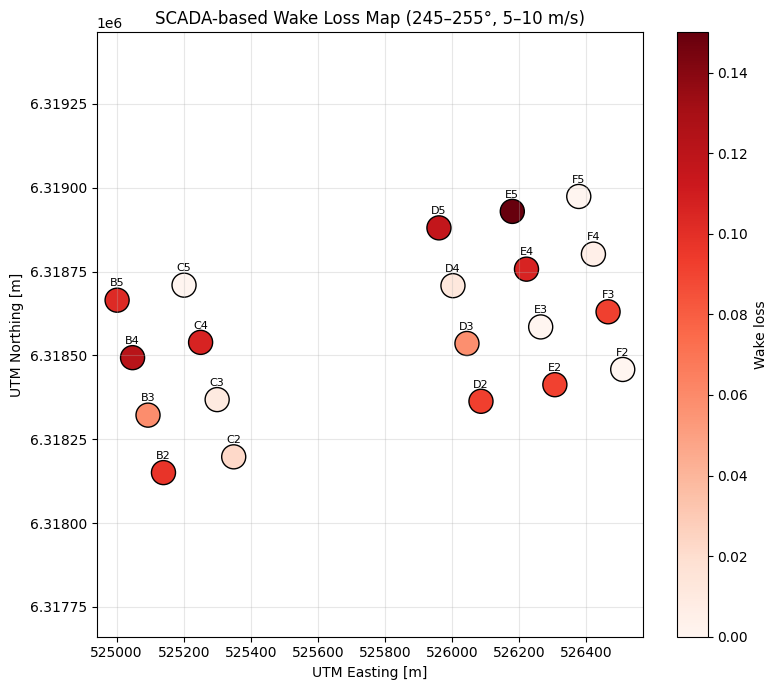

In [ ]:
wake_map_df_valid["wake_loss_plot"] = wake_map_df_valid["wake_loss"].clip(lower=0)

plt.figure(figsize=(8,7))

sc = plt.scatter(
    wake_map_df_valid["x"],
    wake_map_df_valid["y"],
    c=wake_map_df_valid["wake_loss_plot"],
    cmap="Reds",
    s=300,
    edgecolor="black",
    vmin=0,
    vmax=0.15
)

for _, row in wake_map_df_valid.iterrows():
    plt.text(row["x"], row["y"] + 35, row["turbine"].upper(),
             ha="center", va="bottom", fontsize=8)

plt.colorbar(sc, label="Wake loss")
plt.xlabel("UTM Easting [m]")
plt.ylabel("UTM Northing [m]")
plt.title("SCADA-based Wake Loss Map (245–255°, 5–10 m/s)")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()

plt.savefig('../figures/sprint3_wake_loss_map.png', dpi=300)
plt.show()

SCADA-based wake map shows:
- Lighter turbine -> low or near-zero wake loss
- Darker red turbines -> stronger wake loss
- Clipped zero values are shown as light white


The wake-loss map shows the spatial distribution of pairwise wake deficits for the selected inflow conditions (245–255°, 5–10 m/s). Each colored turbine represents the median wake loss relative to its immediate upstream neighbor. The results indicate that wake effects are detectable across multiple turbine chains, with wake losses typically in the range of a few percent up to around 15%. Some downstream turbines show very low or near-zero wake loss, suggesting partial wake recovery, local inflow variability, or SCADA noise.

### 4.10 Directional wake analysis

Since there is a working pipeline for a single sector, it can be looped over for more number of wind direction sectors

In [60]:
sectors = [
    (210,240),
    (240,270),
    (270,300)
]

chains = [
    ["a2", "b2", "c2", "d2", "e2", "f2"],
    ["a3", "b3", "c3", "d3", "e3", "f3"],
    ["a4", "b4", "c4", "d4", "e4", "f4"],
    ["a5", "b5", "c5", "d5", "e5", "f5"],
]

results_directional = []

for sector_min, sector_max in sectors:

    # Filter data for this wind sector and wind speed range
    df_sector = df[
        (df['wind_dir'] >= sector_min) & (df['wind_dir'] < sector_max) &
        (df['wind_speed'] >= 5) & (df['wind_speed'] <= 10)
    ].copy()

    print(f'Sector{sector_min}-{sector_max}$^\circ$: {len(df_sector)} samples')

    for chain in chains:
        row_name = chain[0][-1]

        for i in range(len(chain) - 1):
            up_col = f'{chain[i]}_pow'
            down_col = f'{chain[i+1]}_pow'

            up = df_sector[up_col]
            down = df_sector[down_col]

            valid = (
                (~up.isna())&
                (~down.isna())&
                (up > 20)
            )

            ratio = down[valid] / up[valid]
            ratio = ratio[(ratio > 0) & (ratio < 2)]

            if len(ratio) > 0:
                ratio_median = ratio.median()
                wake_loss = 1 - ratio_median
            else:
                ratio_median = np.nan
                wake_loss = np.nan

            results_directional.append({
                "sector": f"{sector_min}-{sector_max}",
                "sector_min": sector_min,
                "sector_max": sector_max,
                "row": row_name,
                "pair": f"{chain[i+1].upper()} / {chain[i].upper()}",
                "n_samples": len(ratio),
                "ratio_median": ratio_median,
                "wake_loss": wake_loss
            })

Sector210-240$^\circ$: 2071 samples
Sector240-270$^\circ$: 3403 samples
Sector270-300$^\circ$: 2287 samples


<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
C:\Users\szczy\AppData\Local\Temp\ipykernel_19940\3601575817.py:24: SyntaxWarning: invalid escape sequence '\c'
  print(f'Sector{sector_min}-{sector_max}$^\circ$: {len(df_sector)} samples')


**Convert results to dataframe**

In [61]:
directional_wake_df = pd.DataFrame(results_directional)

print(directional_wake_df.shape)
directional_wake_df.head(30)

(60, 8)


,sector,sector_min,sector_max,row,pair,n_samples,ratio_median,wake_loss
0,210-240,210,240,2,B2 / A2,1860,0.900775,0.099225
1,210-240,210,240,2,C2 / B2,1806,0.922763,0.077237
2,210-240,210,240,2,D2 / C2,1758,1.115901,-0.115901
3,210-240,210,240,2,E2 / D2,1880,0.923960,0.076040
4,210-240,210,240,2,F2 / E2,1742,0.913784,0.086216
5,210-240,210,240,3,B3 / A3,1780,0.930344,0.069656
6,210-240,210,240,3,C3 / B3,1803,0.901235,0.098765
7,210-240,210,240,3,D3 / C3,1501,1.098726,-0.098726
8,210-240,210,240,3,E3 / D3,1628,1.014928,-0.014928
9,210-240,210,240,3,F3 / E3,1804,0.865139,0.134861


**Plot wake loss vs sector for each wind turbine pair**

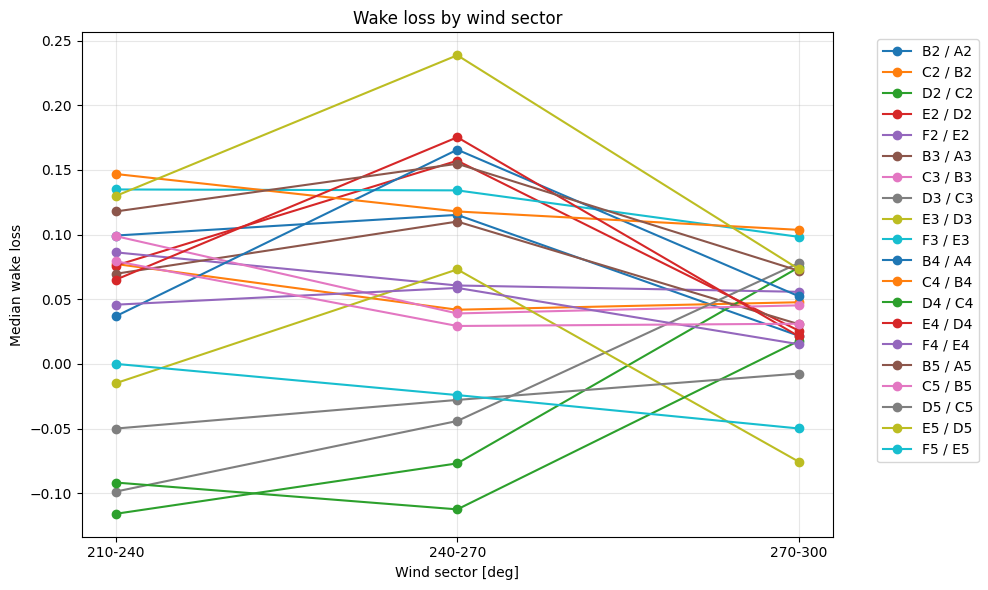

In [ ]:
plt.figure(figsize=(10,6))

for pair in directional_wake_df["pair"].unique():
    subset = directional_wake_df.groupby(["sector", "pair"])["wake_loss"].median().reset_index()
    subset = subset[subset["pair"] == pair]
    
    plt.plot(subset["sector"], subset["wake_loss"], marker="o", label=pair)

plt.ylabel("Median wake loss")
plt.xlabel("Wind sector [deg]")
plt.title("Wake loss by wind sector")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


plt.show()

**A bit cleaner plot: Average by pair position**

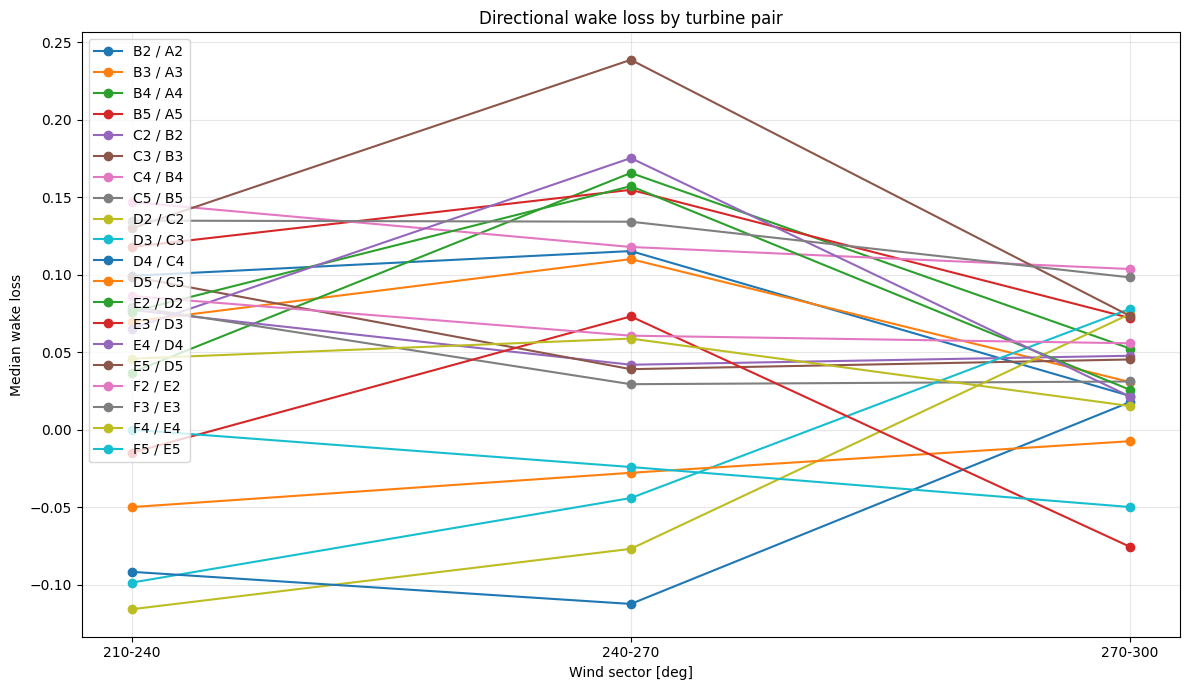

In [ ]:
pair_summary_directional = (
    directional_wake_df
    .groupby(["sector", "pair"])["wake_loss"]
    .median()
    .reset_index()
)

pair_summary_directional

plt.figure(figsize=(12,7))

for pair in pair_summary_directional["pair"].unique():
    subset = pair_summary_directional[pair_summary_directional["pair"] == pair]
    plt.plot(subset["sector"], subset["wake_loss"], marker="o", label=pair)

plt.ylabel("Median wake loss")
plt.xlabel("Wind sector [deg]")
plt.title("Directional wake loss by turbine pair")
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('../figures/sprint3_wake_loss_by_wind_sector.png', dpi=300)
plt.show()

**Heatmap**

In [64]:
heatmap_data = directional_wake_df.pivot_table(
    index = 'pair',
    columns = 'sector',
    values = 'wake_loss',
    aggfunc= 'median'
)

heatmap_data

sector,210-240,240-270,270-300
pair,,,
B2 / A2,0.099225,0.115206,0.021718
B3 / A3,0.069656,0.110033,0.030677
B4 / A4,0.036842,0.165605,0.052315
B5 / A5,0.117855,0.154717,0.072007
C2 / B2,0.077237,0.041868,0.047656
C3 / B3,0.098765,0.038996,0.045261
C4 / B4,0.146805,0.117844,0.103621
C5 / B5,0.079339,0.029307,0.031049
D2 / C2,-0.115901,-0.076923,0.074644


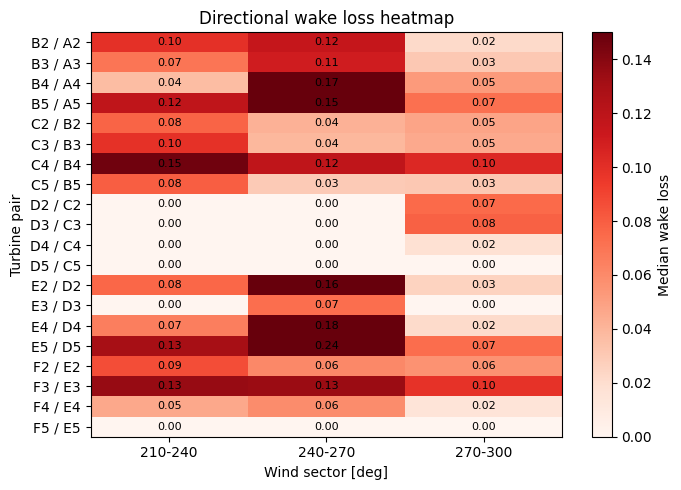

In [ ]:
plt.figure(figsize=(7,5))

# Clip in order to remove 0 values from the heatmap
heatmap_data_plot = heatmap_data.clip(lower=0)

im = plt.imshow(heatmap_data_plot, aspect="auto", cmap="Reds", vmin=0, vmax=0.15)

plt.xticks(range(len(heatmap_data_plot.columns)), heatmap_data_plot.columns)
plt.yticks(range(len(heatmap_data_plot.index)), heatmap_data_plot.index)

for i in range(len(heatmap_data_plot.index)):
    for j in range(len(heatmap_data_plot.columns)):
        val = heatmap_data_plot.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.02f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, label="Median wake loss")
plt.title("Directional wake loss heatmap")
plt.xlabel("Wind sector [deg]")
plt.ylabel("Turbine pair")
plt.tight_layout()

plt.savefig('../figures/sprint3_wake_loss_heatmap.png', dpi=300)
plt.show()

To access how wake effects may vary with inflow direction, the wake loss analysis was repeated for three dominant wind sectors:
- 210-240 deg
- 240-270 deg
- 270-300 deg

For each sector, wake losses were computed using the same turbine chains and filtered wind-speed range (5-10 m/s). This allows comparison of wake behavior as the wind direction rotates relative to the farm layout.

The directional analysis helps identify which wind sector produce the strongest wake interactions and whether wake losses are consistent across multiple turbine rows.

1. Strongest 240-270

This matches what was expected from steps 2 and 3:
- Dominant inflow direction
- Wind aligned with wind turbine rows
- Strongest wake interaction
- Wake losses reaching 24% are realistic with turbines strongly aligned.

2. Weaker wakes in 210-240
- Turbines are less aligned
- Wake partially miss downstream rotors 
- Wake losses are mostly 4-13%

3. Much weaker wakes in 270-300
- Many wake losses drop below 5%
- Some become slightly negative


### 4.11 Wake loss vs downstream distance
- We will convert turbine pairs
- Into relative downstream positions
- Then average across rows


**Step 1 Create a pair type column**

In [71]:
pair_position = {
    "B / A": 1,
    "C / B": 2,
    "D / C": 3,
    "E / D": 4,
    "F / E": 5
}

directional_wake_df["pair_type"] = directional_wake_df["pair"].str.replace(r"\d", "", regex=True)
directional_wake_df[["pair","pair_type"]].head()

,pair,pair_type
0,B2 / A2,B / A
1,C2 / B2,C / B
2,D2 / C2,D / C
3,E2 / D2,E / D
4,F2 / E2,F / E


**Step 2: Map downstream position**

- We apply  the mapping

In [73]:
pair_position = {
    "B / A": 1,
    "C / B": 2,
    "D / C": 3,
    "E / D": 4,
    "F / E": 5
}

directional_wake_df["pair_position"] = directional_wake_df["pair_type"].map(pair_position)
directional_wake_df[["pair","pair_type","pair_position"]].head()

,pair,pair_type,pair_position
0,B2 / A2,B / A,1
1,C2 / B2,C / B,2
2,D2 / C2,D / C,3
3,E2 / D2,E / D,4
4,F2 / E2,F / E,5


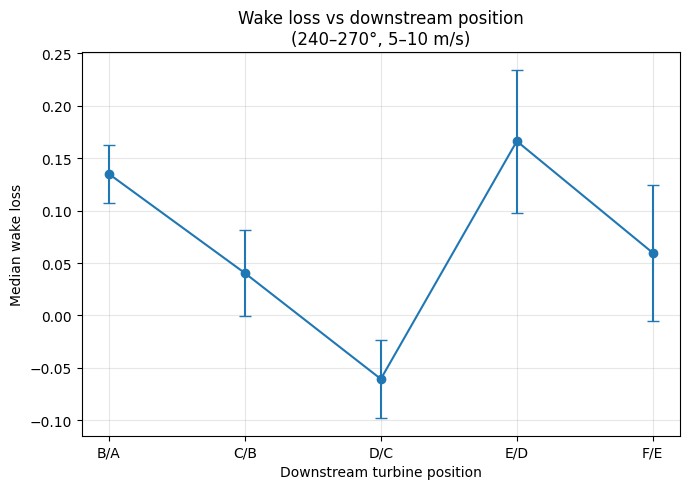

In [78]:
distance_stats = (
    df_strong
    .groupby("pair_position")["wake_loss"]
    .agg(["median","std"])
    .reset_index()
)

plt.figure(figsize=(7,5))

plt.errorbar(
    distance_stats["pair_position"],
    distance_stats["median"],
    yerr=distance_stats["std"],
    marker="o",
    capsize=4
)

plt.xticks([1,2,3,4,5], ["B/A","C/B","D/C","E/D","F/E"])

plt.xlabel("Downstream turbine position")
plt.ylabel("Median wake loss")

plt.title("Wake loss vs downstream position\n(240–270°, 5–10 m/s)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Since there is a bit unexpected jump to 17% of wake in E/D, it is necessary to check the sample sizing.

Since if one pair has fewer samples it can cause sudden median jump.

In [79]:
df_strong.groupby("pair")["n_samples"].median()

pair
B2 / A2    2976.0
B3 / A3    2926.0
B4 / A4    2915.0
B5 / A5    3193.0
C2 / B2    2923.0
C3 / B3    2930.0
C4 / B4    2708.0
C5 / B5    3008.0
D2 / C2    2821.0
D3 / C3    2719.0
D4 / C4    2352.0
D5 / C5    2970.0
E2 / D2    2983.0
E3 / D3    2845.0
E4 / D4    2788.0
E5 / D5    2950.0
F2 / E2    2774.0
F3 / E3    2870.0
F4 / E4    2654.0
F5 / E5    2500.0
Name: n_samples, dtype: float64

Since sample numbers are similar for all the pairs, we can eliminate it as a reason of sudden jump.

Further analysis will be performed. 

A bit smaller bins for wind direction sectors, to see how this affects jump in the results


In [81]:
narrow_sectors = [
    (240, 250),
    (250, 260),
    (260, 270)
]

results_narrow = []

for sector_min, sector_max in narrow_sectors:
    df_sector = df[
        (df["wind_dir"] >= sector_min) & (df["wind_dir"] < sector_max) &
        (df["wind_speed"] >= 5) & (df["wind_speed"] <= 10)
    ].copy()

    for chain in chains:
        for i in range(len(chain) - 1):
            up = df_sector[f"{chain[i]}_pow"]
            down = df_sector[f"{chain[i+1]}_pow"]

            valid = (~up.isna()) & (~down.isna()) & (up > 20)
            ratio = down[valid] / up[valid]
            ratio = ratio[(ratio > 0) & (ratio < 2)]

            results_narrow.append({
                "sector": f"{sector_min}-{sector_max}",
                "pair": f"{chain[i+1].upper()} / {chain[i].upper()}",
                "wake_loss": 1 - ratio.median() if len(ratio) > 0 else np.nan,
                "n_samples": len(ratio)
            })

narrow_df = pd.DataFrame(results_narrow)
narrow_df["pair_type"] = narrow_df["pair"].str.replace(r"\d", "", regex=True)

pair_position = {
    "B / A": 1,
    "C / B": 2,
    "D / C": 3,
    "E / D": 4,
    "F / E": 5
}

narrow_df["pair_position"] = narrow_df["pair_type"].map(pair_position)

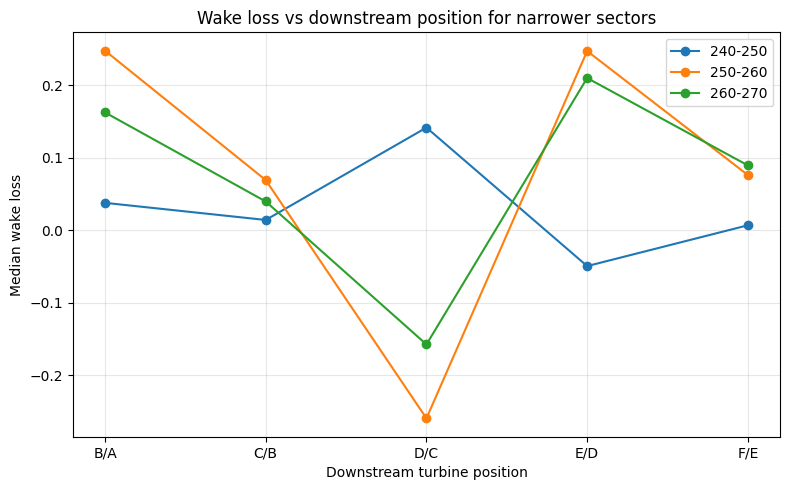

In [ ]:
plt.figure(figsize=(8,5))

for sector in narrow_df["sector"].unique():
    subset = (
        narrow_df[narrow_df["sector"] == sector]
        .groupby("pair_position")["wake_loss"]
        .median()
        .reset_index()
    )

    plt.plot(subset["pair_position"], subset["wake_loss"], marker="o", label=sector)

plt.xticks([1,2,3,4,5], ["B/A","C/B","D/C","E/D","F/E"])
plt.xlabel("Downstream turbine position")
plt.ylabel("Median wake loss")
plt.title("Wake loss vs downstream position for narrower sectors")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('../figures/sprint3_wake_loss_narrower_sectors.png', dpi=300)
plt.show()

**What can be seen**
- Farm rows are only well aligned with wind around ~245$^\circ$
- Since farm is not perfectly rectangular, few degree rotations can shift overlap
- At 240-250, wind is aligned with rows so row propagation is (A-B-C-D-E-F)
- At 250-260 / 260-270, wind rotates slightly so turbines are not perfectly aligned and wind can hit wind turbines like A-B-C-E or A-B-D
    - That breaks the monotonic downstream pattern

- So this result proves something important, that:
    - Wake chains only exist for a narrow directional window
    - So we discovered **effective alignment window**

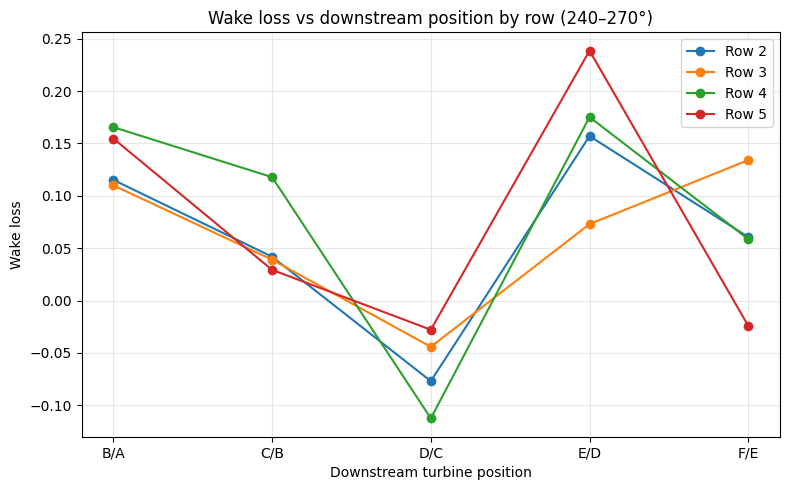

In [ ]:
df_strong = directional_wake_df[directional_wake_df["sector"] == "240-270"].copy()
df_strong["pair_type"] = df_strong["pair"].str.replace(r"\d", "", regex=True)
df_strong["pair_position"] = df_strong["pair_type"].map(pair_position)

plt.figure(figsize=(8,5))

for row in sorted(df_strong["row"].unique()):
    subset = (
        df_strong[df_strong["row"] == row]
        .sort_values("pair_position")
    )
    plt.plot(subset["pair_position"], subset["wake_loss"], marker="o", label=f"Row {row}")

plt.xticks([1,2,3,4,5], ["B/A","C/B","D/C","E/D","F/E"])
plt.xlabel("Downstream turbine position")
plt.ylabel("Wake loss")
plt.title("Wake loss vs downstream position by row (240–270°)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('../figures/sprint3_wake_loss_narrower_sectors_all_chains.png', dpi=300)
plt.show()

## Conclusions - Wake analysis

This analysis investigated wake effects in the DTU wind farm SCADA dataset by combining turbine power data, wind direction measurements and turbine layout geometry. The objective was to identify upstream-downstream turbine interactions and quantify wake-included power losses under different wind conditions

The analysis focused on dominant wind sectors and used filtered SCADA data to estimate wake losses between turbine pairs along aligned turbine chains.

**Wake loss magnitude**

Across multiple turbine rows, wake losses were consistently detected using SCADA power ratios. Typical wake losses ranged between approximately
- 5-10% for moderate affected turbines
- 10-20% for turbines strongly aligned with upstream machines

These values are consistent with expected wake deficits for turbines spaced approximately 7-8 diameters apart, which matches documented spacing of the wind farm.

**Directional dependence of wake effects**

The directional wake analysis revealed a strong dependence of wake losses on wind direction.

The largest wake deficits were observed in the sector:

**240-270**

This sector corresponds to the dominant inflow direction identified earlier in the wind statistics analysis. Within this range, several turbines pairs showed wake losses exceeding 15-20% indicating strong wake interactions across multiple turbine rows.

However further investigation showed that wake propagation along turbine chains become most consistent when wind direction is narrowed to approximately:

**240-250**

Within this narrower sector, turbines are closely aligned with the farm rows, allowing wake effects to propagate more clearly from upstream to downstream turbines.

For wider sectors (250–270°), wake patterns become less consistent due to small directional shifts that alter turbine alignment.

**Wake propagation along turbine chains**

The downstream wake analysis showed that wake losses do not increase monotonically along the turbine chain. Instead, wake losses vary between turbine pairs due to several physical factors:

- turbulence-induced wake recovery

- partial wake overlap

- slight misalignment of turbine rows

- directional variability within wind sectors

Although the first downstream turbine often experiences a significant deficit, wake losses further downstream can fluctuate depending on how the wake interacts with subsequent turbines.

This behavior is typical for SCADA-based wake studies and reflects the complexity of real wind farm flow dynamics.


**Spatial distribution of wake losses**

The SCADA-based wake-loss map confirmed that wake effects occur across multiple turbine rows. Downstream turbines located deeper within the farm generally experience higher wake losses when the wind aligns with the turbine rows.

The spatial wake map provides a practical visualization of how wake interactions propagate through the wind farm under specific inflow conditions.

**Limitations**
Several limitations of SCADA-based wake analysis should be noted:

- SCADA data provides indirect measurements of wake effects through turbine power output rather than direct flow measurements.

- Wind direction bins contain a range of inflow angles, which can blur alignment between turbines.

- Turbulence, atmospheric conditions, and measurement noise introduce variability into wake-loss estimates.

- The analysis assumes pairwise turbine interactions and does not explicitly model multi-wake superposition effects.

Despite these limitations, SCADA data remains a valuable tool for detecting wake behavior and assessing wind farm performance.